Description...

In [5]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')


import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
from typing import List, Tuple

# Preliminary

In [3]:
BASE_PATH = '/lhome/ific/c/ccortesp/Data/Muon_Veto/test_modules/'

### Base Functions


In [9]:
def _calculate_rate_details_for_file( h5_path         : str
                                    , label           : str = ""
                                    , plot_timestamps : bool = True ):
    """Calculate event rates for one HDF5 run and optionally plot timestamp gaps.

    Timestamps are expected in milliseconds. Gaps longer than ten seconds are
    removed by keeping the largest contiguous block of events.

    Args:
        h5_path: HDF5 file containing the ``data`` table.
        label: Human-readable name used in the timestamp plot.
        plot_timestamps: Whether to display kept and discarded events.

    Returns:
        A dictionary containing measured, lost and corrected rates and counts.
    """
    filename = os.path.basename(h5_path)
    stats = {
        'measured_rate': 0.0,
        'lost_rate': 0.0,
        'corrected_rate': 0.0,
        'events_registered': 0,
        'events_lost': 0,
        'time_sec': 0.0,
        'is_cleaned': False,
        'events_dropped': 0
    }

    try:
        df_raw = pd.read_hdf(h5_path, 'data')
        
        if df_raw.empty or 'timestamp' not in df_raw.columns or 'lostBuffer' not in df_raw.columns:
            print(f"      [!] Error: Missing data or required columns in {filename}")
            return stats

        # --- 1. Detect and Clean Gaps ---
        df_sorted = df_raw.sort_values(by=['timestamp']).copy()
        gap_threshold_ms = 10.0 * 1000  # Timestamps are stored in milliseconds.
        
        deltas = df_sorted['timestamp'].diff()
        group_ids = (deltas > gap_threshold_ms).cumsum()
        df_sorted['group_id'] = group_ids 
        
        group_counts = df_sorted['group_id'].value_counts()
        winner_group_id = group_counts.idxmax()     # Largest group is considered the "good" data
        data_df = df_sorted[df_sorted['group_id'] == winner_group_id].copy()

        stats['is_cleaned'] = len(group_counts) > 1
        stats['events_dropped'] = len(df_sorted) - len(data_df)

        if stats['is_cleaned']:
            print(f"      [!] Gap Cleaning Triggered: Removed {len(group_counts)-1} gap cluster(s). Dropped {stats['events_dropped']} events.")

        # --- 2. Plot Timestamp Distribution ---
        if plot_timestamps and not df_sorted.empty:
            t_start = df_sorted['timestamp'].iloc[0]
            all_times_min = (df_sorted['timestamp'] - t_start) / 60000.0 
            
            mask_kept = df_sorted['group_id'] == winner_group_id
            mask_discarded = ~mask_kept
            
            times_kept = all_times_min[mask_kept]
            times_discarded = all_times_min[mask_discarded]
            
            plt.style.use('ggplot')
            plt.figure(figsize=(10, 5))
            bins = np.linspace(all_times_min.min(), all_times_min.max(), 100)
            
            if len(times_discarded) > 0:
                plt.hist(times_discarded, bins=bins, color='red', alpha=1.0, 
                         label=f'Discarded ({stats["events_dropped"]} evts)')
            
            plt.hist(times_kept, bins=bins, color='blue', alpha=0.6, 
                     label=f'Kept Data ({len(times_kept)} evts)')
            
            plt.title(f"Events Timestamps | {label} | File: {filename}")
            plt.xlabel("Time since file start (min)")
            plt.ylabel("Counts")
            # plt.yscale('log')
            plt.grid(True, which="both", linestyle='--', alpha=0.5)
            plt.tight_layout()
            plt.show()

        if data_df.empty:
            return stats

        # --- 3. Calculate Detailed Rates ---
        first_timestamp = data_df['timestamp'].iloc[0]
        last_timestamp = data_df['timestamp'].iloc[-1]
        time_difference = (last_timestamp - first_timestamp) * 0.001    # In [s]

        if time_difference > 0:
            events_registered = len(data_df)
            events_lost = data_df['lostBuffer'].fillna(0).sum()
            total_events_estimated = events_registered + events_lost
            
            stats['time_sec'] = time_difference
            stats['events_registered'] = events_registered
            stats['events_lost'] = int(events_lost)
            stats['measured_rate'] = events_registered / time_difference
            stats['lost_rate'] = events_lost / time_difference
            stats['corrected_rate'] = total_events_estimated / time_difference
            
        return stats
            
    except Exception as e:
        print(f"  [!] Error processing {filename}: {e}")
        print(f"      [!] Could not calculate rate for {filename}: {e}")
        return stats

def _plot_charge_histogram_for_file( h5_path         : str
                                   , label           : str = ""
                                   , signal_channels : List[int] = []
                                   , ref_channels    : List[int] = []
                                   , plot_range      : Tuple[float, float] = (10, 2000)
                                   , bins            : int = 200
                                   , log_scale       : bool = True ):
    """Plot charge distributions for the active and control channels."""
    filename = os.path.basename(h5_path)

    try:
        with h5py.File(h5_path, "r") as f:
            if "charges" not in f:
                print(f"  [!] Warning: 'charges' dataset not found in {filename}.")
                return

            charges = f["charges"][:]

        if charges.size == 0 or charges.ndim != 2:
            print(f"  [!] Warning: No data or insufficient columns in {filename}.")
            return

        if signal_channels is None:
            signal_channels = [0, 1]
        if ref_channels is None:
            ref_channels = [10]

        requested_channels = list(signal_channels) + list(ref_channels)
        invalid_channels = [
            channel for channel in requested_channels
            if channel < 0 or channel >= charges.shape[1]
        ]

        if invalid_channels:
            print(
                f"  [!] Warning: Invalid channel(s) {invalid_channels} "
                f"for {filename}; dataset has {charges.shape[1]} channels."
            )
            return

        plt.style.use("ggplot")
        plt.figure(figsize=(12, 7))

        bin_edges = np.linspace(plot_range[0], plot_range[1], bins + 1)
        signal_colors = [
            "red", "orange", "limegreen", "navy",
            "darkorchid", "deeppink", "black", "aqua"
        ]

        for channel_number in ref_channels:
            plt.hist(
                charges[:, channel_number],
                bins=bin_edges,
                histtype="step",
                linewidth=2,
                color="silver",
                label=f"Channel {channel_number} (Electronic Noise)",
            )

        for index, channel_number in enumerate(signal_channels):
            plt.hist(
                charges[:, channel_number],
                bins=bin_edges,
                histtype="step",
                linewidth=1.0,
                color=signal_colors[index % len(signal_colors)],
                linestyle="-",
                label=f"Channel {channel_number} (Signal)",
            )

        plt.title(f"Charge Distribution | {label} | File: {filename}")
        plt.xlabel("Charge (ADC Counts)")
        plt.ylabel("Frequency (Counts)")
        plt.yscale("log") if log_scale else plt.yscale("linear")
        plt.xlim(plot_range[0], plot_range[1])
        plt.legend()
        plt.grid(True, which="both", linestyle="--")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"  [!] Error processing {filename}: {e}")

def _analyze_all_channels( h5_path              : str
                         , label                : str = ""
                         , signal_threshold_adc : float = 250.0
                         , plot_range           : Tuple[float, float] = (10, 2000)
                         , bins                 : int = 200
                         , log_scale            : bool = True):
    """
    Classify every readout channel and plot its charge distribution.

    A channel is classified as active when its 99.9th-percentile charge
    reaches the signal threshold. Lower but statistically significant
    distributions are classified as dark noise; the remainder are treated
    as unconnected electronic channels.

    Args:
        h5_path: HDF5 file containing the two-dimensional ``charges`` dataset.
        label: Human-readable name shown in the report and plot.
        signal_threshold_adc: Charge above which a channel is considered active.
        plot_range: Lower and upper ADC limits for the histograms.
        bins: Number of histogram bins.
        log_scale: Whether to use a logarithmic scale for the y-axis.
    """
    filename = os.path.basename(h5_path)

    try:
        with h5py.File(h5_path, "r") as f:
            if "charges" not in f:
                print(f"  [!] Warning: 'charges' dataset not found in {filename}.")
                return

            # Load 2D array: (N_events, N_channels)
            charges = f["charges"][:]

        if charges.size == 0 or charges.ndim != 2:
            print(f"  [!] Warning: Empty or invalid dataset shape in {filename}")
            return

        n_events, n_channels = charges.shape
        print(f"\n--- Module Commissioning Report: {filename} ({n_events} events, {n_channels} readout channels) ---\n")

        signal_bars       = []
        dark_noise_bars   = []
        unconnected_bars  = []

        channel_metrics = {}
        for channel_index in range(n_channels):
            channel_readouts = charges[:, channel_index]
            # -----------------------
            # 1. Handle Passive Zeros
            # -----------------------
            positive_readouts = channel_readouts[channel_readouts > 0]
            # Compute pedestal from non-zero readouts
            if len(positive_readouts) < (0.01 * n_events):
                # Channel is practically always 0 ADC ---> Dead
                ped_median = 0.0;   ped_sigma  = 1.0
                snr_upper  = 0.0;   max_charge = 0.0
                p99_charge = 0.0;   signal_hits = 0
            else:
                ped_median = np.percentile(positive_readouts, 50)
                ped_sigma  = max(ped_median - np.percentile(positive_readouts, 15.9), 1.2)

                p84_charge = np.percentile(positive_readouts, 84.1)
                snr_upper  = (p84_charge - ped_median) / ped_sigma

                p99_charge = np.percentile(positive_readouts, 99.9)

            # -------------------------
            # 2. Extract Signal Metrics
            # -------------------------
            # Cosmic scintillation counts (high light yield from ionizing particles)
            signal_hits = (channel_readouts > signal_threshold_adc).sum()
            max_charge  = np.max(channel_readouts)

            channel_metrics[channel_index] = {
                "ped_median"   : ped_median,
                "ped_sigma"    : ped_sigma,
                "snr_upper"    : snr_upper,
                "max_charge"   : max_charge,
                "p99_charge"   : p99_charge,
                "signal_hits"  : signal_hits,
            }

            # --------------------------
            # 3. Physical Decision Logic
            # --------------------------
            if (p99_charge >= signal_threshold_adc):
                signal_bars.append(channel_index)

            elif ((p99_charge > ped_median + 6.0 * ped_sigma) or (snr_upper >= 1.20)) and (p99_charge < signal_threshold_adc):
                dark_noise_bars.append(channel_index)

            else:
                unconnected_bars.append(channel_index)

        # --------------------
        # Diagnostics Printout
        # --------------------
        print(f"[✓] ACTIVE BARS (Cosmic Scintillation)  [{len(signal_bars)}]: {signal_bars}")
        for channel_index in signal_bars:
            channel_metrics_for_printing = channel_metrics[channel_index]
            print(f"  • Ch {channel_index}: Ped. Median: {channel_metrics_for_printing['ped_median']:.2f} ADC | Ped. Sigma: {channel_metrics_for_printing['ped_sigma']:.2f} ADC | SNR: {channel_metrics_for_printing['snr_upper']:.2f} | Max. Charge: {channel_metrics_for_printing['max_charge']} ADC | P99 Charge: {channel_metrics_for_printing['p99_charge']:.2f} ADC | Signal Hits: {channel_metrics_for_printing['signal_hits']}")

        print(f"\n[!] DARK NOISE (SiPM biased, NO light) [{len(dark_noise_bars)}]: {dark_noise_bars}")
        for channel_index in dark_noise_bars:
            channel_metrics_for_printing = channel_metrics[channel_index]
            print(f"  • Ch {channel_index}: Ped. Median: {channel_metrics_for_printing['ped_median']:.2f} ADC | Ped. Sigma: {channel_metrics_for_printing['ped_sigma']:.2f} ADC | SNR: {channel_metrics_for_printing['snr_upper']:.2f} | Max. Charge: {channel_metrics_for_printing['max_charge']} ADC | P99 Charge: {channel_metrics_for_printing['p99_charge']:.2f} ADC | Signal Hits: {channel_metrics_for_printing['signal_hits']}")

        print(f"\n[x] UNCONNECTED (Pure Electronic Noise) [{len(unconnected_bars)}]: {unconnected_bars}")
        for channel_index in unconnected_bars:
            channel_metrics_for_printing = channel_metrics[channel_index]
            print(f"  • Ch {channel_index}: Ped. Median: {channel_metrics_for_printing['ped_median']:.2f} ADC | Ped. Sigma: {channel_metrics_for_printing['ped_sigma']:.2f} ADC | SNR: {channel_metrics_for_printing['snr_upper']:.2f} | Max. Charge: {channel_metrics_for_printing['max_charge']} ADC | P99 Charge: {channel_metrics_for_printing['p99_charge']:.2f} ADC | Signal Hits: {channel_metrics_for_printing['signal_hits']}")
            
        # ----------------
        # 4. Visualization
        # ----------------
        plt.style.use("ggplot")
        fig, ax = plt.subplots(figsize=(16, 8))
        bin_edges = np.linspace(plot_range[0], plot_range[1], bins + 1)
        warm_colors = [ 'lightcoral', 'red', 'orangered', 'darkorange', 
                        'gold', 'yellowgreen', 'limegreen', 'seagreen' ]
        cool_colors = [ 'aqua', 'deepskyblue', 'steelblue', 'royalblue',
                        'navy', 'rebeccapurple', 'mediumorchid', 'deeppink' ]

        # A. Unconnected channels (electronic-noise reference)
        for ch in unconnected_bars:
            ax.hist(
                charges[:, ch],
                bins=bin_edges,
                histtype="step",
                color='silver',
                linewidth=1.0,
                linestyle="-",
                label=f"Ch {ch} (Unconnected)",
            )

        # B. Dark Noise Channels (Uncoupled SiPMs)
        for i, ch in enumerate(dark_noise_bars):
            color = warm_colors[i % len(warm_colors)]
            ax.hist(
                charges[:, ch],
                bins=bin_edges,
                histtype="step",
                color=color,
                linewidth=1.5,
                linestyle=":",
                label=f"Ch {ch} (Dark Noise)",
            )

        # C. Channels with signal
        for i, ch in enumerate(signal_bars):
            color = cool_colors[i % len(cool_colors)]
            ax.hist(
                charges[:, ch],
                bins=bin_edges,
                histtype="step",
                color=color,
                lw=2.0,
                linestyle="-",
                label=f"Ch {ch} (Signal)",
                zorder=3
            )

        # Visual boundary between low-energy dark noise and high-energy cosmic scintillation
        ax.axvline(
            signal_threshold_adc,
            color="crimson",
            linestyle="--",
            linewidth=1.0,
            label=f"Signal Cutoff ({signal_threshold_adc:.0f} ADC)",
        )

        ax.set_title(
            f"{label} | Signal: {len(signal_bars)} | Dark Noise: {len(dark_noise_bars)} | Unconnected: {len(unconnected_bars)}",
            fontsize=15, loc='left'
        )
        ax.set_xlabel("Charge (ADC)", fontsize=12)
        ax.set_ylabel("Counts", fontsize=12)
        ax.set_yscale("log") if log_scale else ax.set_yscale("linear")
        ax.set_xlim(plot_range[0], plot_range[1])

        ax.legend(
            loc="upper right",
            fontsize=10,
            facecolor="white",
        )
        ax.grid(True, which="both", linestyle="--", alpha=0.5)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"  [!] Error processing {filename}: {e}")


### Main Functions


In [16]:
def analyze_bars( directory       : str
                , selected_runs   : List[int] = []
                , signal_channels : List[int] = []
                , ref_channels    : List[int] = []
                , plot_range      : Tuple[float, float] = (10, 2000)
                , bins            : int = 200
                , log_scale       : bool = True ):
    """
    Compare loss-corrected event rates for selected bar runs.
    
    Args:
        directory: Folder containing files named ``muons_run_<number>.h5``.
        selected_runs: Run numbers to include. If None, include every valid run.
        signal_channels: Channel indices to plot as signal. Defaults to [0, 1].
        reference_noise_channels: Channel indices for electronic-noise
            references. Defaults to [10].
    """
    directory = os.path.normpath(directory)
    if not os.path.isdir(directory):
        print(f"Error: Directory not found: {directory}")
        return

    print(f"\n{'='*60}")
    print(f"--- Custom Run Analysis Mode ---")
    print(f"{'='*60}")

    # --- 1. Find and Filter Files ---
    all_files = os.listdir(directory)
    run_files_info = []
    
    for filename in all_files:
        if filename.startswith('muons_run_') and filename.endswith('.h5'):
            match = re.search(r'muons_run_(\d+)\.h5', filename)
            if match:
                run_number = int(match.group(1))
                # If selected_runs is provided, filter out unwanted runs
                if selected_runs is None or run_number in selected_runs:
                    run_files_info.append({'filename': filename, 'run_number': run_number})

    # Sort files by run number
    run_files_info.sort(key=lambda x: x['run_number'])

    if not run_files_info:
        print("No valid runs found matching your criteria.")
        return

    print(f"Found {len(run_files_info)} files to analyze.")
    print("-" * 60)
    
    run_labels = []
    corrected_rates = []
    cleaned_flags = []
    
    # --- 2. Calculate Detailed Rates & Plot Timestamps ---
    for file_info in run_files_info:
        run_number = file_info['run_number']
        filename = file_info['filename']
        file_path = os.path.join(directory, filename)
        
        label = f"Run {run_number}"
        run_labels.append(label)
        
        print(f"[{label}] Using file: {filename}")
        
        rate_stats = _calculate_rate_details_for_file(file_path, label, plot_timestamps=True)
        
        corrected_rates.append(rate_stats['corrected_rate'])
        cleaned_flags.append(rate_stats['is_cleaned'])
        
        print(f"      Analyzed Time : {rate_stats['time_sec']:.2f} seconds")
        print(f"      Events Saved  : {rate_stats['events_registered']}")
        print(f"      Events Lost   : {rate_stats['events_lost']} (from lostBuffer)")
        print(f"      Measured Rate : {rate_stats['measured_rate']:.2f} Hz")
        print(f"      Lost Rate     : {rate_stats['lost_rate']:.2f} Hz (+ added by efficiency)")
        print(f"      FINAL RATE    : {rate_stats['corrected_rate']:.2f} Hz\n")

    # --- 3. Plot Final Corrected Rates Bar Chart ---
    plt.style.use('ggplot')
    plt.figure(figsize=(max(10, len(run_labels)*1.2), 6)) # Dynamically resize if many files
    
    bars = plt.bar(run_labels, corrected_rates, color='royalblue')
    
    plt.ylabel('Corrected Rate (Hz)')
    plt.title('Corrected Event Rates for Custom Selected Runs')
    
    for idx, bar in enumerate(bars):
        yval = bar.get_height()
        label_text = f'{yval:.2f} Hz'
        if cleaned_flags[idx]:
            label_text += '\n(Cleaned)'
            
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + (yval*0.02), label_text, va='bottom', ha='center', fontweight='bold', fontsize=9)

    max_rate = max(corrected_rates) if corrected_rates else 100
    plt.ylim(0, max_rate * 1.15) 
    plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
    plt.tight_layout()
    plt.show()

    # --- 4. Plot Charge Distributions ---
    print("-" * 60)
    print("Generating charge distribution plots...")
    for file_info in run_files_info:
        run_number = file_info['run_number']
        filename = file_info['filename']
        file_path = os.path.join(directory, filename)
        label = f"Run {run_number}"
        
        _plot_charge_histogram_for_file(
            file_path,
            label,
            signal_channels=signal_channels,
            ref_channels=ref_channels,
            plot_range=(plot_range[0], plot_range[1]),
            bins=bins,
            log_scale=log_scale
        )
        
    print("\n--- Custom Analysis Complete ---\n")

def analyze_modules( directory       : str
                   , selected_runs   : List[int] = []
                   , threshold       : float = 250.0
                   , plot_range      : Tuple[float, float] = (10, 2000)
                   , bins            : int = 200
                   , log_scale       : bool = True ):
    """
    Classify channels and compare corrected rates for selected module runs.
    
    Args:
        directory: Folder containing files named ``muons_run_<number>.h5``.
        selected_runs: Run numbers to include. If None, include every valid run.
        threshold: ADC threshold passed to the channel classifier.
    """
    directory = os.path.normpath(directory)
    if not os.path.isdir(directory):
        print(f"Error: Directory not found: {directory}")
        return

    print(f"\n{'='*60}")
    print(f"--- Custom Run Analysis Mode ---")
    print(f"{'='*60}")

    # --- 1. Find and Filter Files ---
    all_files = os.listdir(directory)
    run_files_info = []
    
    for filename in all_files:
        if filename.startswith('muons_run_') and filename.endswith('.h5'):
            match = re.search(r'muons_run_(\d+)\.h5', filename)
            if match:
                run_number = int(match.group(1))
                # If selected_runs is provided, filter out unwanted runs
                if selected_runs is None or run_number in selected_runs:
                    run_files_info.append({'filename': filename, 'run_number': run_number})

    # Sort files by run number
    run_files_info.sort(key=lambda x: x['run_number'])

    if not run_files_info:
        print("No valid runs found matching your criteria.")
        return

    print(f"Found {len(run_files_info)} files to analyze.")
    print("-" * 60)
    
    run_labels = []
    corrected_rates = []
    cleaned_flags = []
    
    # --- 2. Calculate Detailed Rates & Plot Timestamps ---
    for file_info in run_files_info:
        run_number = file_info['run_number']
        filename = file_info['filename']
        file_path = os.path.join(directory, filename)
        
        label = f"Run {run_number}"
        run_labels.append(label)
        
        print(f"[{label}] Using file: {filename}")
        
        rate_stats = _calculate_rate_details_for_file(file_path, label, plot_timestamps=True)
        
        corrected_rates.append(rate_stats['corrected_rate'])
        cleaned_flags.append(rate_stats['is_cleaned'])
        
        print(f"      Analyzed Time : {rate_stats['time_sec']:.2f} seconds")
        print(f"      Events Saved  : {rate_stats['events_registered']}")
        print(f"      Events Lost   : {rate_stats['events_lost']} (from lostBuffer)")
        print(f"      Measured Rate : {rate_stats['measured_rate']:.2f} Hz")
        print(f"      Lost Rate     : {rate_stats['lost_rate']:.2f} Hz (+ added by efficiency)")
        print(f"      FINAL RATE    : {rate_stats['corrected_rate']:.2f} Hz\n")

    # --- 3. Plot Final Corrected Rates Bar Chart ---
    plt.style.use('ggplot')
    plt.figure(figsize=(max(10, len(run_labels)*1.2), 6)) # Dynamically resize if many files
    
    bars = plt.bar(run_labels, corrected_rates, color='royalblue')
    
    plt.ylabel('Corrected Rate (Hz)')
    plt.title('Corrected Event Rates for Custom Selected Runs')
    
    for idx, bar in enumerate(bars):
        yval = bar.get_height()
        label_text = f'{yval:.2f} Hz'
        if cleaned_flags[idx]:
            label_text += '\n(Cleaned)'
            
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + (yval*0.02), label_text, va='bottom', ha='center', fontweight='bold', fontsize=9)

    max_rate = max(corrected_rates) if corrected_rates else 100
    plt.ylim(0, max_rate * 1.15) 
    plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
    plt.tight_layout()
    plt.show()

    # --- 4. Plot Charge Distributions ---
    print("-" * 60)
    print("Generating charge distribution plots...")
    for file_info in run_files_info:
        run_number = file_info['run_number']
        filename = file_info['filename']
        file_path = os.path.join(directory, filename)
        label = f"Run {run_number}"

        _analyze_all_channels(
            file_path,
            label,
            signal_threshold_adc=threshold,
            plot_range=(plot_range[0], plot_range[1]),
            bins=bins,
            log_scale=log_scale
        )
    
    print(f"\n{'='*60}")
    print("--- Custom Analysis Complete ---")
    print(f"{'='*60}")


# Module 1

In [5]:
FILENAMES = ['muons_run_552.h5', 'muons_run_553.h5']
FILE_PATHS = [os.path.join(BASE_PATH, fname) for fname in FILENAMES]

In [6]:
test_df = pd.read_hdf(FILE_PATHS[0], 'data')
test_df

,timestamp,card,eventT0,eventT1,overflowT0,overflowT1,t0,t1,lostBuffer,lostFGPA
0,1788961953374,71,0,0,1,1,1046038557,1046038557,0,0
1,1788961953374,71,0,0,1,1,1046186440,1046186440,0,0
2,1788961953374,71,0,0,1,1,1046220475,1046220475,0,0
3,1788961953374,71,0,0,1,1,1046257778,1046257778,0,0
4,1788961953374,71,0,0,1,1,1046336235,1046336235,0,0
...,...,...,...,...,...,...,...,...,...,...
82117,1788961988227,71,0,0,1,1,1031874070,1031874070,0,0
82118,1788961988227,71,0,0,1,1,1031900710,1031900710,0,0
82119,1788961988227,71,0,0,1,1,1031928964,1031928964,0,0
82120,1788961988227,71,0,0,1,1,1031978544,1031978544,0,0


In [7]:
with h5py.File(FILE_PATHS[0], "r") as f:

    # Read the 'charges' dataset into a NumPy array
    charges_df = f["charges"][:]

In [8]:
ch_raw = charges_df[:, 0]  # Extract the first channel (column) of the 2D array
ch_raw

array([282,  56, 251, ...,   0,   0,   0], dtype=int16)

In [9]:
ch_raw = ch_raw[ch_raw > 0]  # Filter out zero values
ch_raw

array([282,  56, 251, ..., 191, 348, 390], dtype=int16)


--- Custom Run Analysis Mode ---
Found 2 files to analyze.
------------------------------------------------------------
[Run 552] Using file: muons_run_552.h5


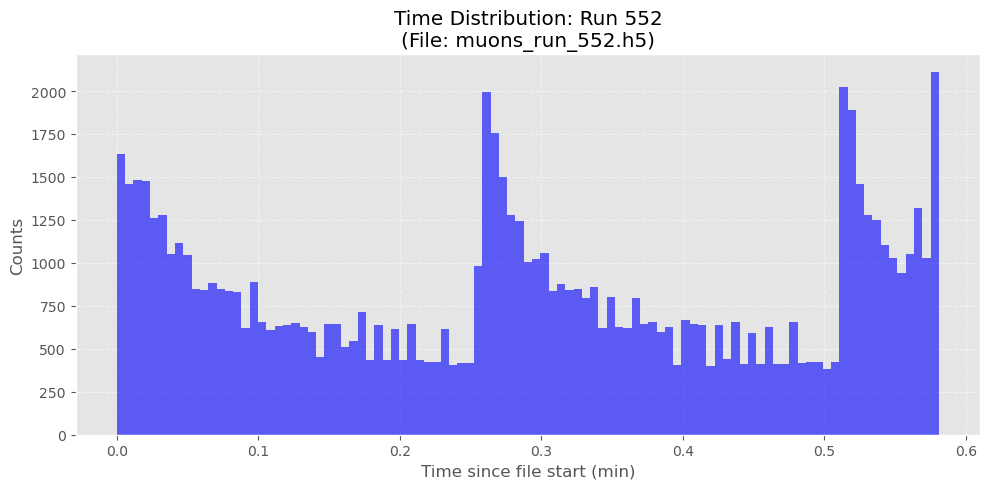

      Analyzed Time : 34.85 seconds
      Events Saved  : 82122
      Events Lost   : 1051 (from lostBuffer)
      Measured Rate : 2356.24 Hz
      Lost Rate     : 30.16 Hz (+ added by efficiency)
      FINAL RATE    : 2386.39 Hz

[Run 565] Using file: muons_run_565.h5


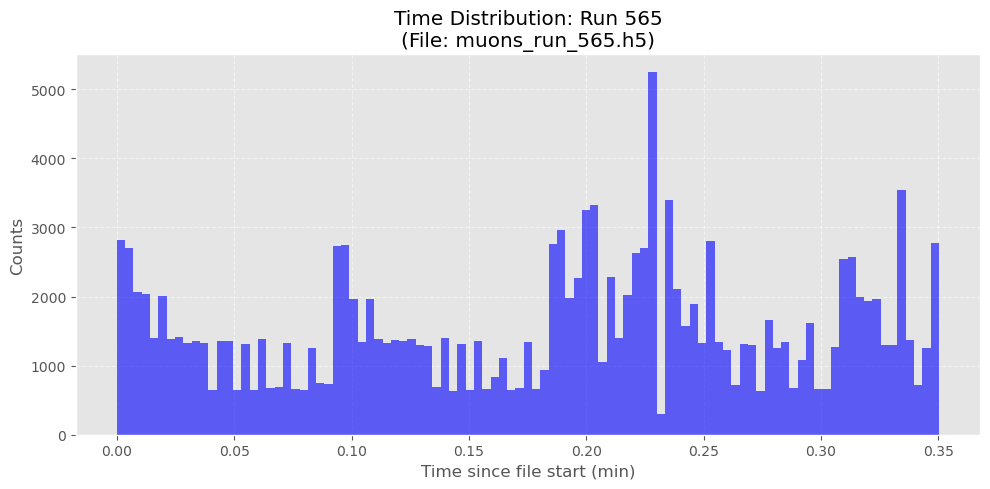

      Analyzed Time : 21.02 seconds
      Events Saved  : 154363
      Events Lost   : 3169 (from lostBuffer)
      Measured Rate : 7345.02 Hz
      Lost Rate     : 150.79 Hz (+ added by efficiency)
      FINAL RATE    : 7495.81 Hz



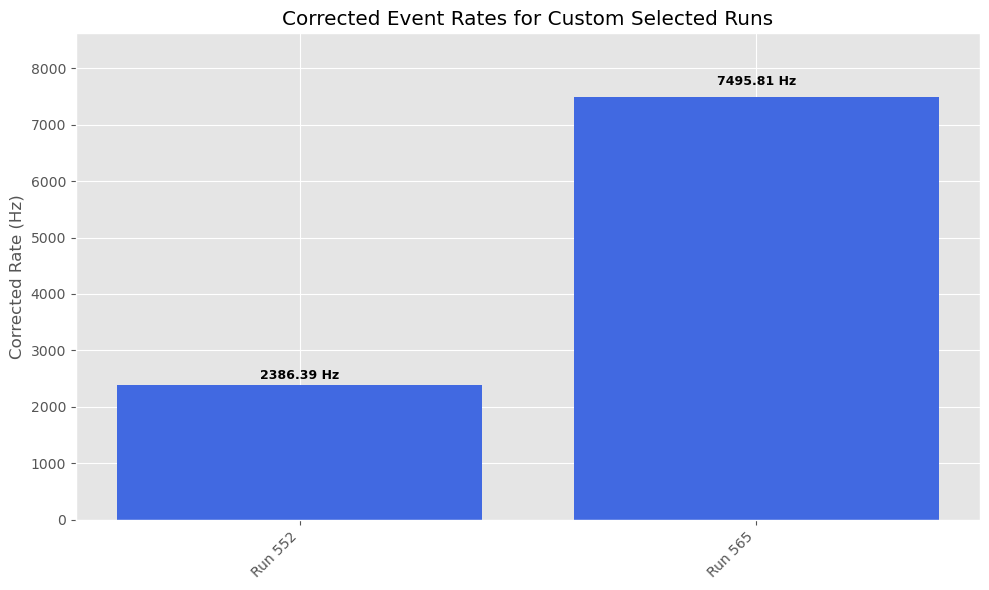

------------------------------------------------------------
Generating charge distribution plots...

--- Module Commissioning Report: muons_run_552.h5 (82122 events, 32 readout channels) ---

[✓] ACTIVE BARS (Cosmic Scintillation)  [18]: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
  • Ch 0: Ped. Median: 216.00 ADC | Ped. Sigma: 62.00 ADC | SNR: 1.26 | Max. Charge: 956 ADC | P99 Charge: 730.44 ADC | Signal Hits: 1655
  • Ch 1: Ped. Median: 235.00 ADC | Ped. Sigma: 88.00 ADC | SNR: 1.28 | Max. Charge: 1129 ADC | P99 Charge: 852.60 ADC | Signal Hits: 4052
  • Ch 2: Ped. Median: 246.00 ADC | Ped. Sigma: 105.00 ADC | SNR: 1.31 | Max. Charge: 1179 ADC | P99 Charge: 933.00 ADC | Signal Hits: 6134
  • Ch 3: Ped. Median: 253.00 ADC | Ped. Sigma: 113.00 ADC | SNR: 1.35 | Max. Charge: 1298 ADC | P99 Charge: 1084.34 ADC | Signal Hits: 7365
  • Ch 4: Ped. Median: 236.00 ADC | Ped. Sigma: 112.00 ADC | SNR: 1.44 | Max. Charge: 1256 ADC | P99 Charge: 982.50 ADC | Signal Hits: 7018


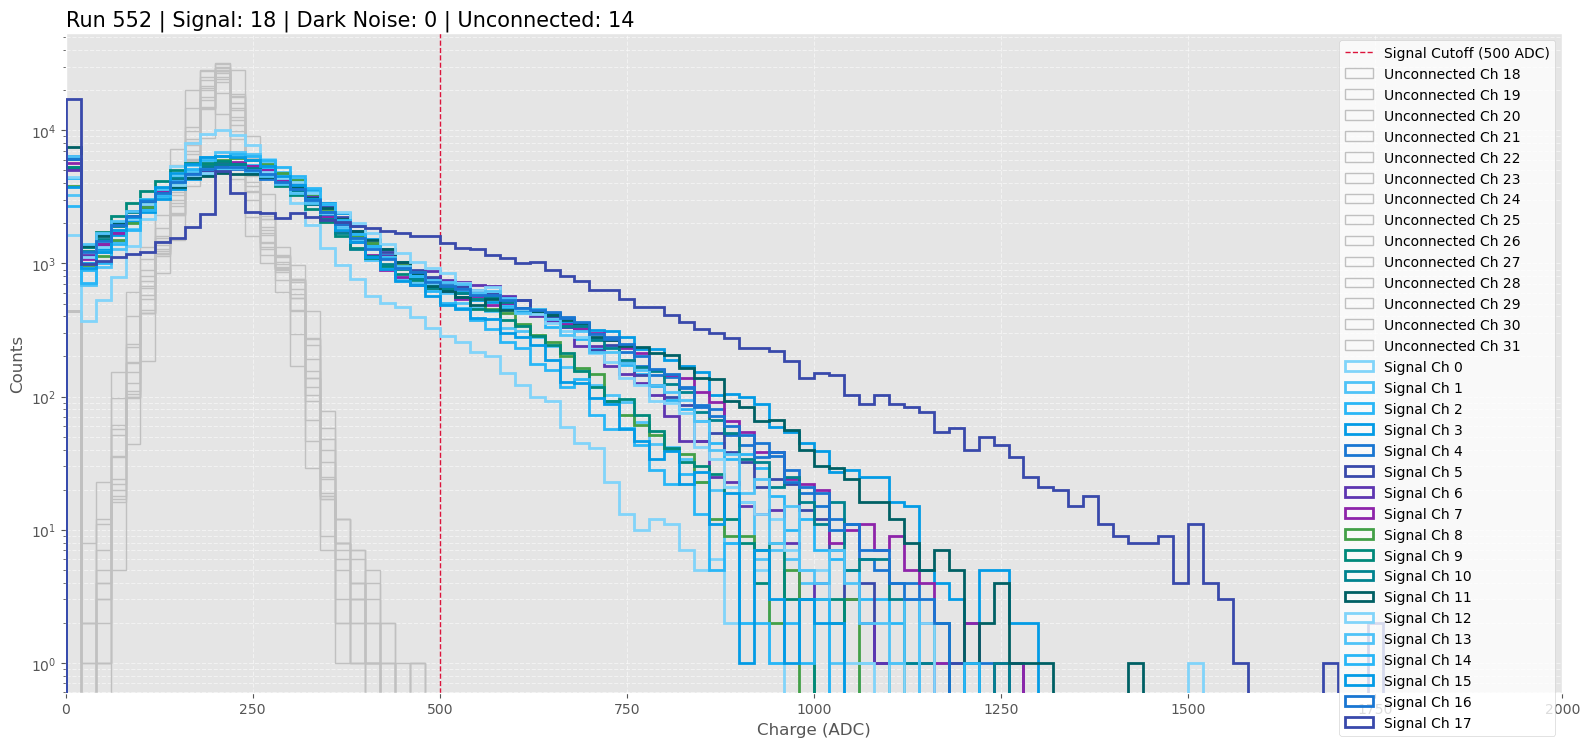


--- Module Commissioning Report: muons_run_565.h5 (154363 events, 32 readout channels) ---

[✓] ACTIVE BARS (Cosmic Scintillation)  [18]: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
  • Ch 0: Ped. Median: 219.00 ADC | Ped. Sigma: 63.00 ADC | SNR: 1.22 | Max. Charge: 1110 ADC | P99 Charge: 755.00 ADC | Signal Hits: 2718
  • Ch 1: Ped. Median: 237.00 ADC | Ped. Sigma: 88.00 ADC | SNR: 1.22 | Max. Charge: 1279 ADC | P99 Charge: 864.71 ADC | Signal Hits: 6443
  • Ch 2: Ped. Median: 238.00 ADC | Ped. Sigma: 94.00 ADC | SNR: 1.21 | Max. Charge: 1497 ADC | P99 Charge: 877.00 ADC | Signal Hits: 6749
  • Ch 3: Ped. Median: 245.00 ADC | Ped. Sigma: 103.00 ADC | SNR: 1.27 | Max. Charge: 1487 ADC | P99 Charge: 1030.00 ADC | Signal Hits: 9875
  • Ch 4: Ped. Median: 230.00 ADC | Ped. Sigma: 105.00 ADC | SNR: 1.25 | Max. Charge: 1295 ADC | P99 Charge: 940.00 ADC | Signal Hits: 8146
  • Ch 5: Ped. Median: 239.00 ADC | Ped. Sigma: 102.00 ADC | SNR: 1.22 | Max. Charge: 1506 ADC | P99

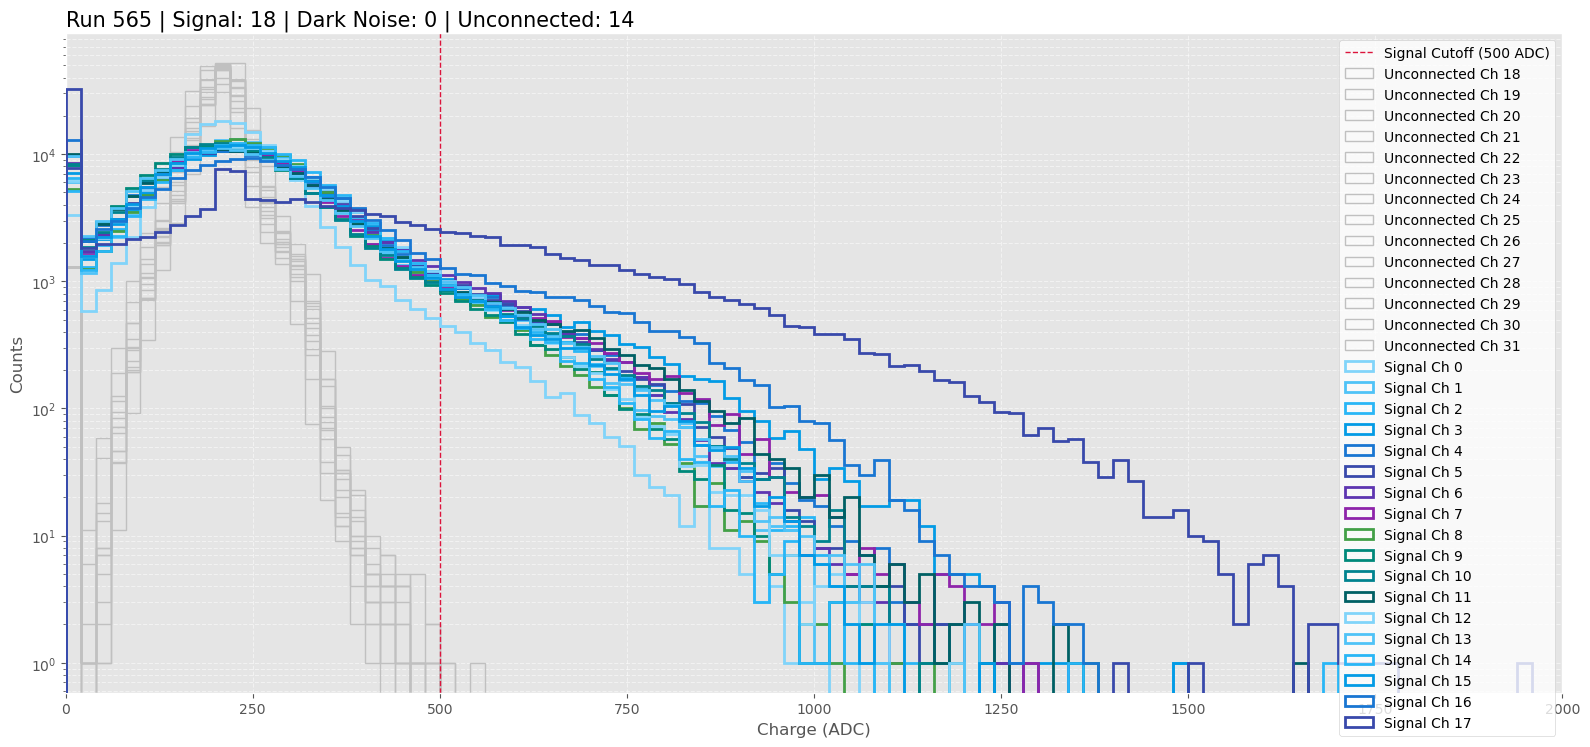


--- Custom Analysis Complete ---


In [10]:
analyze_modules(BASE_PATH, selected_runs=[552, 565], threshold=500)

# Module 2


--- Custom Run Analysis Mode ---
Found 1 files to analyze.
------------------------------------------------------------
[Run 619] Using file: muons_run_619.h5


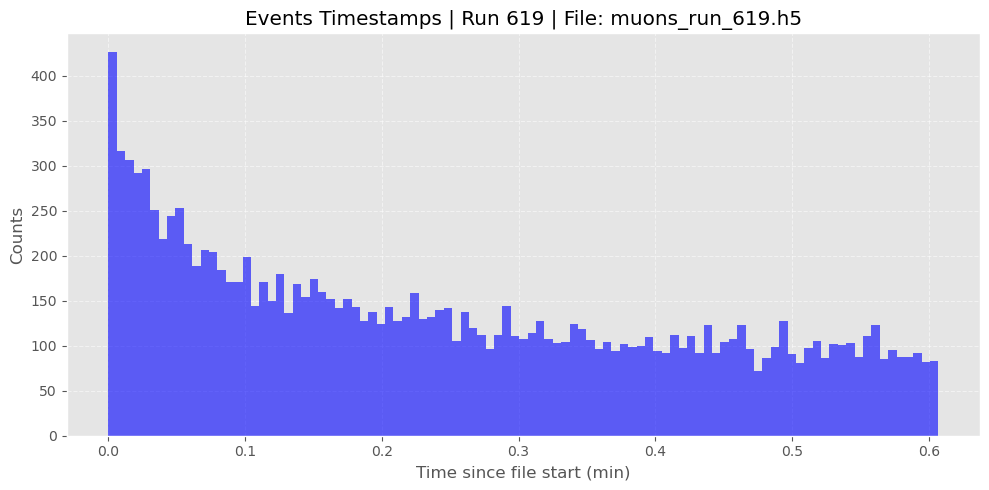

      Analyzed Time : 36.42 seconds
      Events Saved  : 13647
      Events Lost   : 5 (from lostBuffer)
      Measured Rate : 374.68 Hz
      Lost Rate     : 0.14 Hz (+ added by efficiency)
      FINAL RATE    : 374.82 Hz



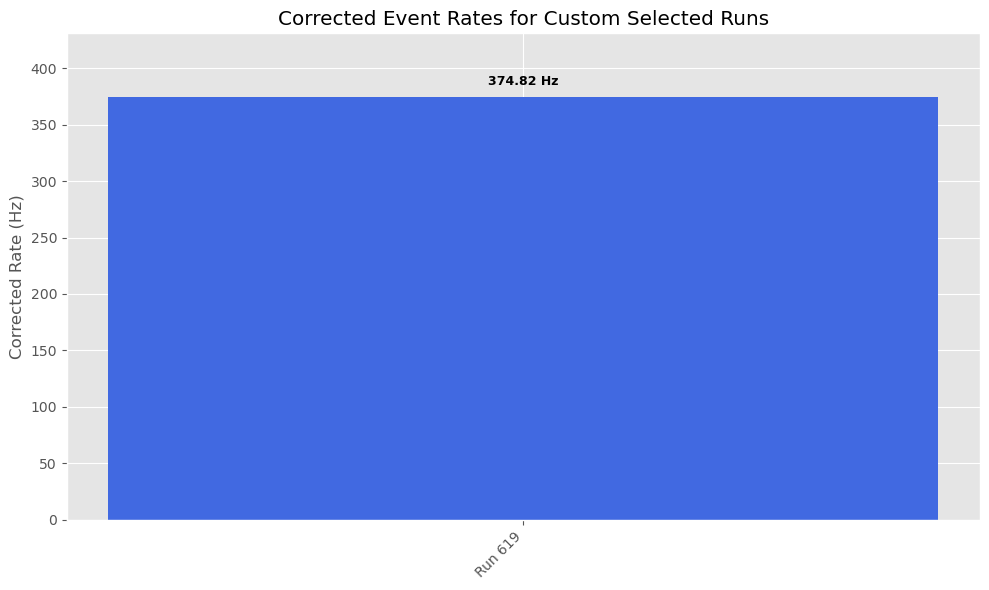

------------------------------------------------------------
Generating charge distribution plots...

--- Module Commissioning Report: muons_run_619.h5 (13647 events, 32 readout channels) ---

[✓] ACTIVE BARS (Cosmic Scintillation)  [0]: []

[!] DARK NOISE (SiPM biased, NO light) [23]: [2, 3, 4, 5, 8, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 23, 24, 26, 27, 28, 29, 31]
  • Ch 2: Ped. Median: 192.00 ADC | Ped. Sigma: 31.00 ADC | SNR: 1.23 | Max. Charge: 695 ADC | P99 Charge: 622.81 ADC | Signal Hits: 0
  • Ch 3: Ped. Median: 166.00 ADC | Ped. Sigma: 32.00 ADC | SNR: 1.22 | Max. Charge: 670 ADC | P99 Charge: 623.39 ADC | Signal Hits: 0
  • Ch 4: Ped. Median: 153.00 ADC | Ped. Sigma: 28.00 ADC | SNR: 1.04 | Max. Charge: 478 ADC | P99 Charge: 419.25 ADC | Signal Hits: 0
  • Ch 5: Ped. Median: 185.00 ADC | Ped. Sigma: 36.00 ADC | SNR: 1.19 | Max. Charge: 629 ADC | P99 Charge: 534.54 ADC | Signal Hits: 0
  • Ch 8: Ped. Median: 169.00 ADC | Ped. Sigma: 28.00 ADC | SNR: 1.14 | Max. Charge: 

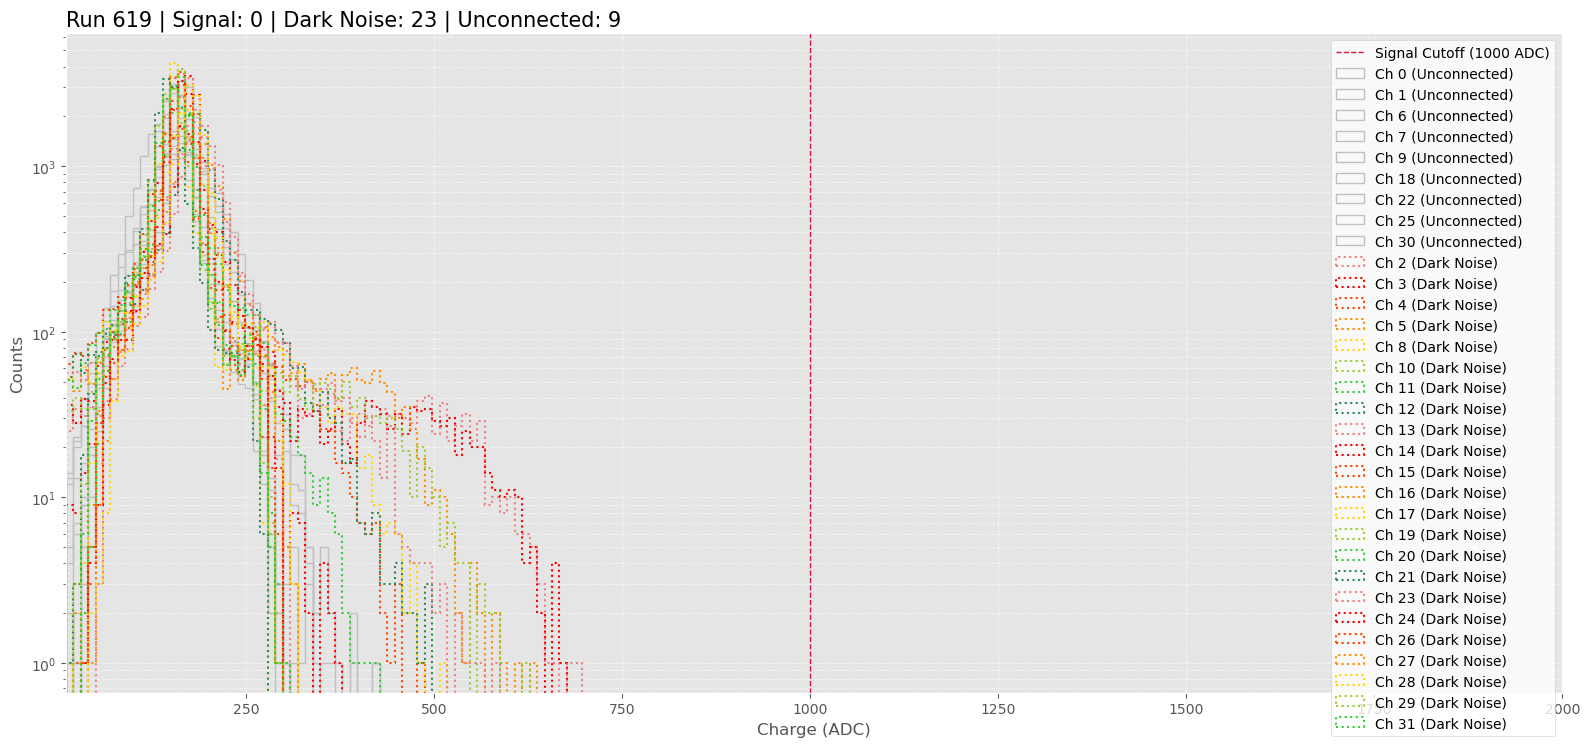


--- Custom Analysis Complete ---


In [20]:
analyze_modules(BASE_PATH, selected_runs=[619], threshold=1000)

# Module 3


--- Custom Run Analysis Mode ---
Found 2 files to analyze.
------------------------------------------------------------
[Run 560] Using file: muons_run_560.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 471 events.


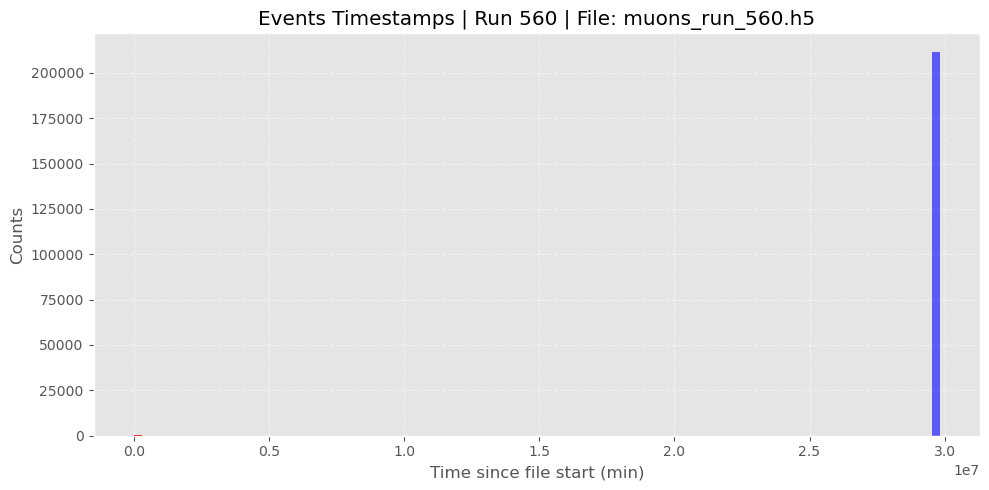

      Analyzed Time : 18.93 seconds
      Events Saved  : 211203
      Events Lost   : 2853312 (from lostBuffer)
      Measured Rate : 11157.05 Hz
      Lost Rate     : 150729.64 Hz (+ added by efficiency)
      FINAL RATE    : 161886.69 Hz

[Run 563] Using file: muons_run_563.h5


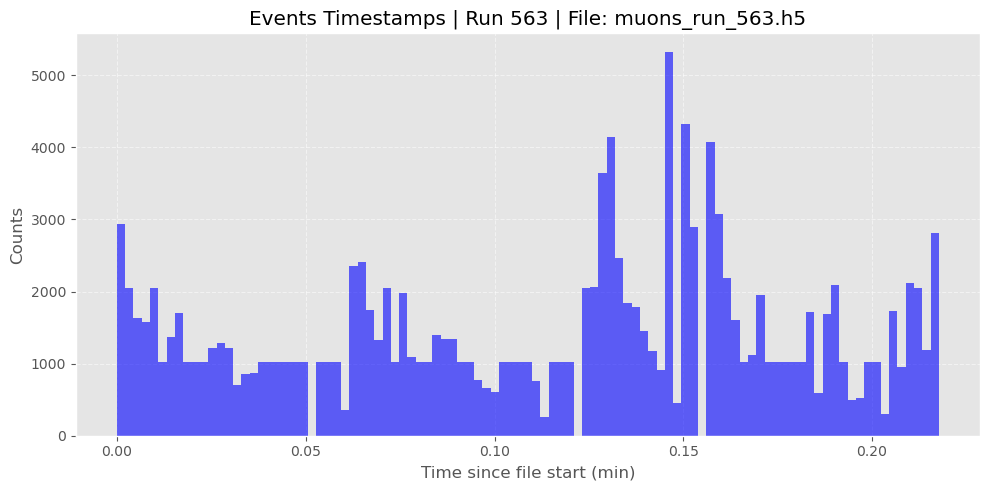

      Analyzed Time : 13.06 seconds
      Events Saved  : 141561
      Events Lost   : 1796413 (from lostBuffer)
      Measured Rate : 10838.45 Hz
      Lost Rate     : 137540.23 Hz (+ added by efficiency)
      FINAL RATE    : 148378.68 Hz



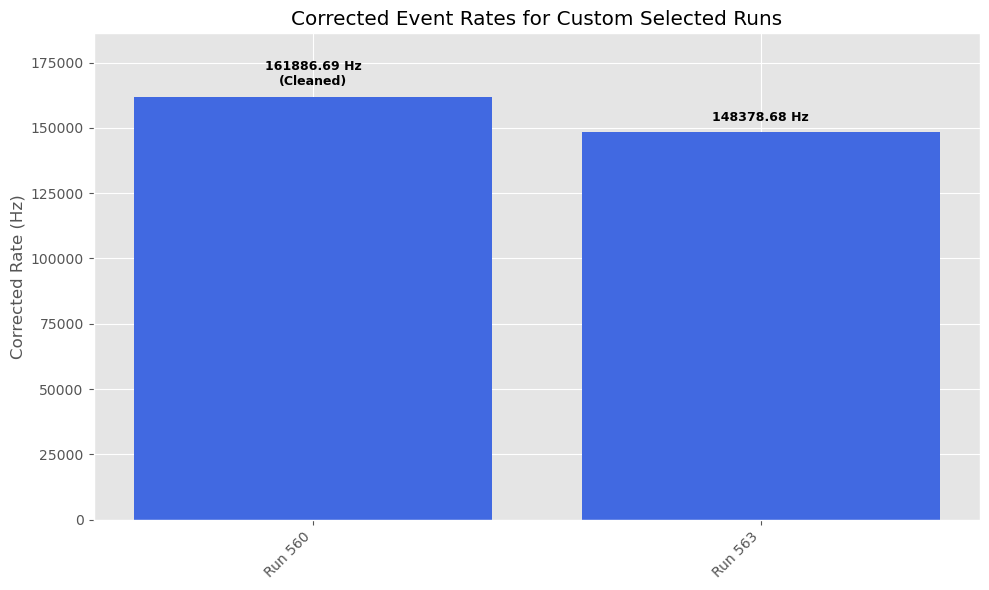

------------------------------------------------------------
Generating charge distribution plots...

--- Module Commissioning Report: muons_run_560.h5 (211674 events, 32 readout channels) ---

[✓] ACTIVE BARS (Cosmic Scintillation)  [1]: [2]
  • Ch 2: Ped. Median: 225.00 ADC | Ped. Sigma: 31.00 ADC | SNR: 0.58 | Max. Charge: 1024 ADC | P99 Charge: 567.00 ADC | Signal Hits: 376

[!] DARK NOISE (SiPM biased, NO light) [24]: [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
  • Ch 8: Ped. Median: 238.00 ADC | Ped. Sigma: 33.00 ADC | SNR: 2.42 | Max. Charge: 624 ADC | P99 Charge: 448.00 ADC | Signal Hits: 11
  • Ch 9: Ped. Median: 217.00 ADC | Ped. Sigma: 28.00 ADC | SNR: 3.11 | Max. Charge: 573 ADC | P99 Charge: 429.00 ADC | Signal Hits: 6
  • Ch 10: Ped. Median: 214.00 ADC | Ped. Sigma: 42.00 ADC | SNR: 1.81 | Max. Charge: 564 ADC | P99 Charge: 418.00 ADC | Signal Hits: 2
  • Ch 11: Ped. Median: 226.00 ADC | Ped. Sigma: 33.00 ADC | SNR: 2.97 

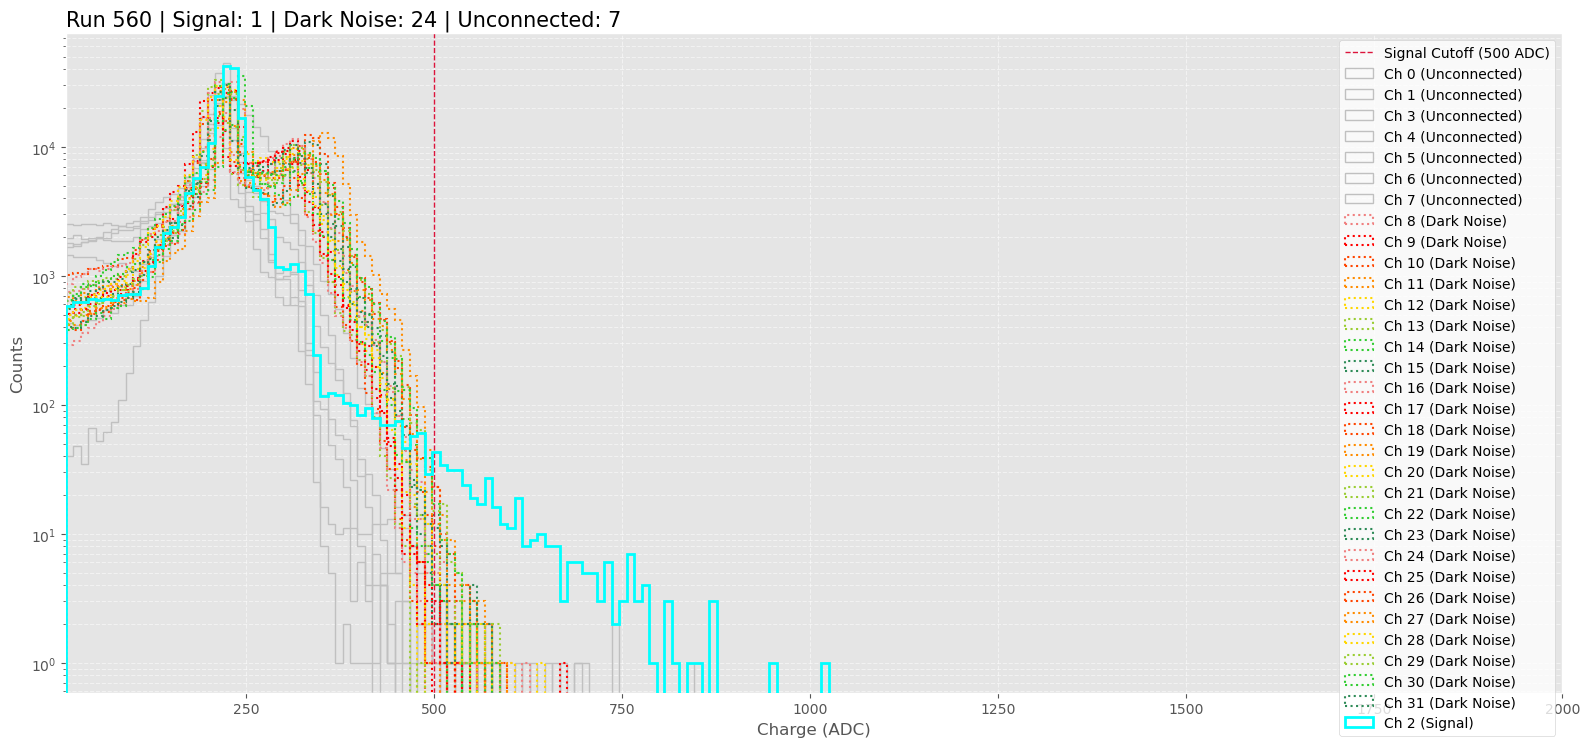


--- Module Commissioning Report: muons_run_563.h5 (141561 events, 32 readout channels) ---

[✓] ACTIVE BARS (Cosmic Scintillation)  [1]: [2]
  • Ch 2: Ped. Median: 226.00 ADC | Ped. Sigma: 29.00 ADC | SNR: 0.59 | Max. Charge: 1165 ADC | P99 Charge: 526.71 ADC | Signal Hits: 183

[!] DARK NOISE (SiPM biased, NO light) [24]: [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
  • Ch 8: Ped. Median: 238.00 ADC | Ped. Sigma: 34.00 ADC | SNR: 2.41 | Max. Charge: 554 ADC | P99 Charge: 449.00 ADC | Signal Hits: 6
  • Ch 9: Ped. Median: 217.00 ADC | Ped. Sigma: 27.00 ADC | SNR: 3.33 | Max. Charge: 566 ADC | P99 Charge: 431.00 ADC | Signal Hits: 8
  • Ch 10: Ped. Median: 215.00 ADC | Ped. Sigma: 41.00 ADC | SNR: 1.95 | Max. Charge: 533 ADC | P99 Charge: 420.00 ADC | Signal Hits: 4
  • Ch 11: Ped. Median: 226.00 ADC | Ped. Sigma: 33.00 ADC | SNR: 3.06 | Max. Charge: 657 ADC | P99 Charge: 443.69 ADC | Signal Hits: 10
  • Ch 12: Ped. Median: 236.00 ADC |

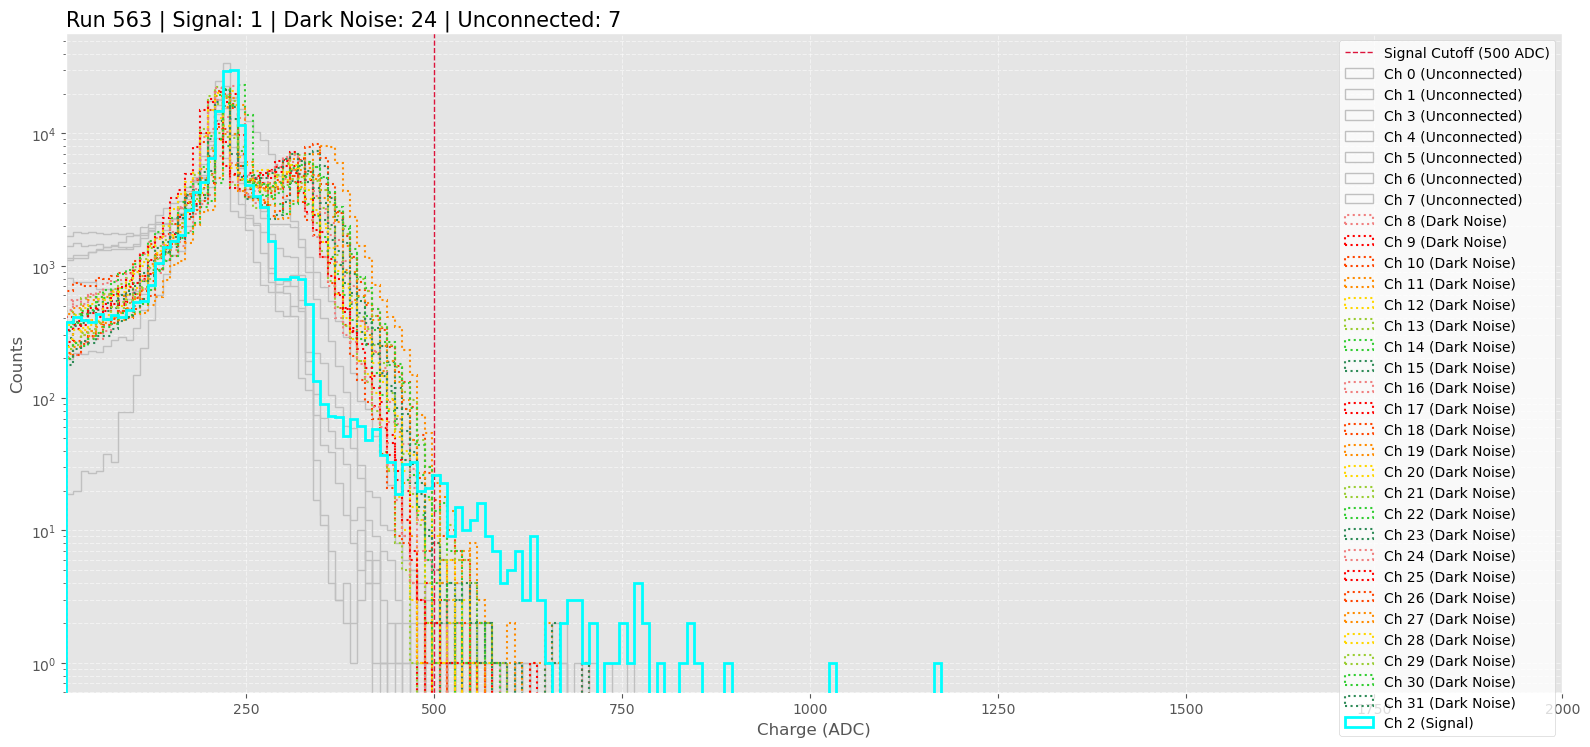


--- Custom Analysis Complete ---


In [12]:
analyze_modules(BASE_PATH, selected_runs=[560, 563], threshold=500)

### Individual Bars


--- Custom Run Analysis Mode ---
Found 19 files to analyze.
------------------------------------------------------------
[Run 586] Using file: muons_run_586.h5


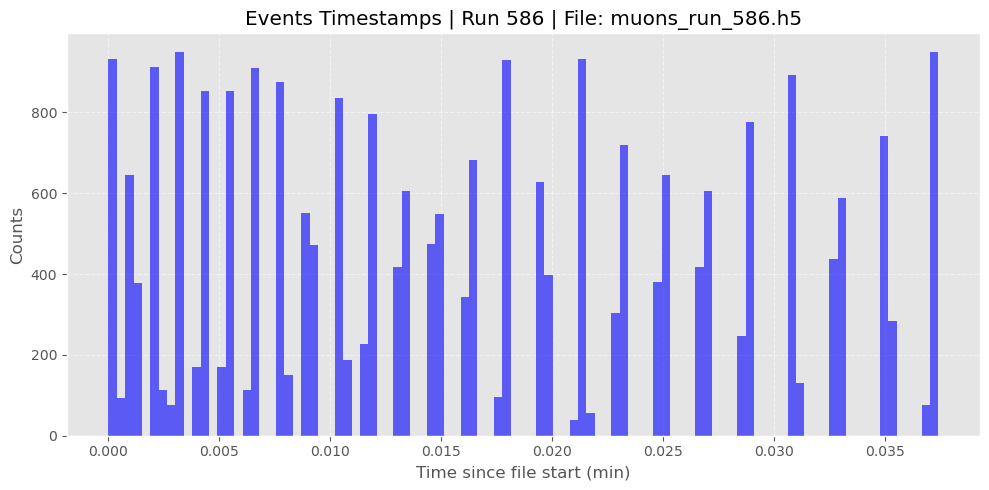

      Analyzed Time : 2.25 seconds
      Events Saved  : 25600
      Events Lost   : 85841 (from lostBuffer)
      Measured Rate : 11403.12 Hz
      Lost Rate     : 38236.53 Hz (+ added by efficiency)
      FINAL RATE    : 49639.64 Hz

[Run 587] Using file: muons_run_587.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 310 events.


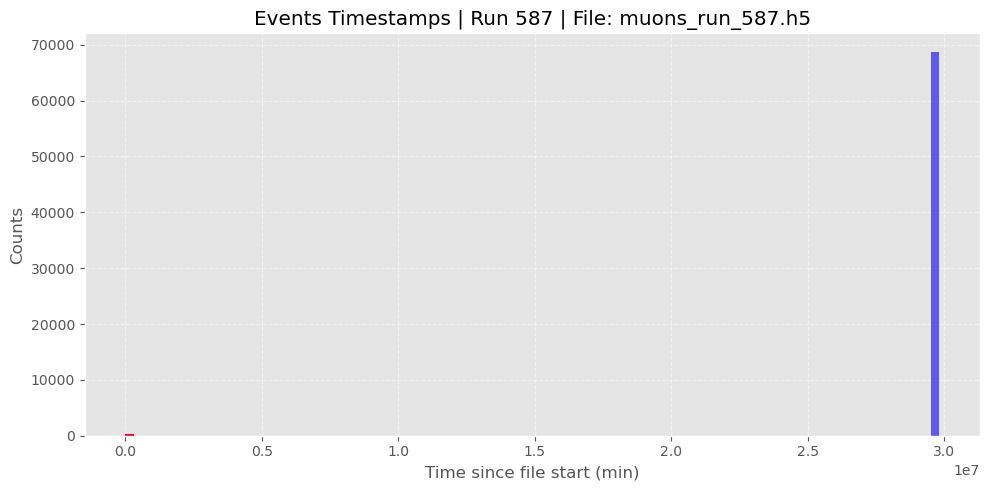

      Analyzed Time : 6.96 seconds
      Events Saved  : 68608
      Events Lost   : 450506 (from lostBuffer)
      Measured Rate : 9857.47 Hz
      Lost Rate     : 64727.87 Hz (+ added by efficiency)
      FINAL RATE    : 74585.34 Hz

[Run 588] Using file: muons_run_588.h5


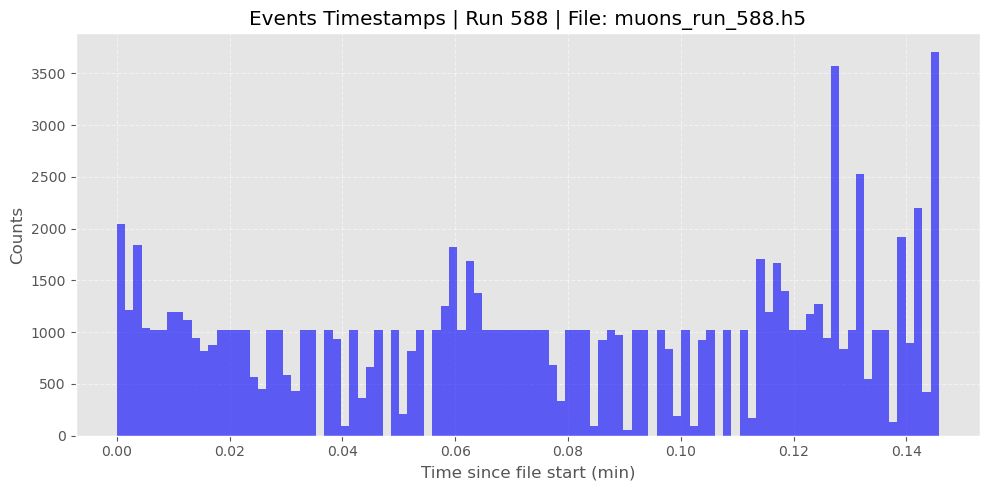

      Analyzed Time : 8.75 seconds
      Events Saved  : 96931
      Events Lost   : 634989 (from lostBuffer)
      Measured Rate : 11081.63 Hz
      Lost Rate     : 72595.06 Hz (+ added by efficiency)
      FINAL RATE    : 83676.69 Hz

[Run 589] Using file: muons_run_589.h5


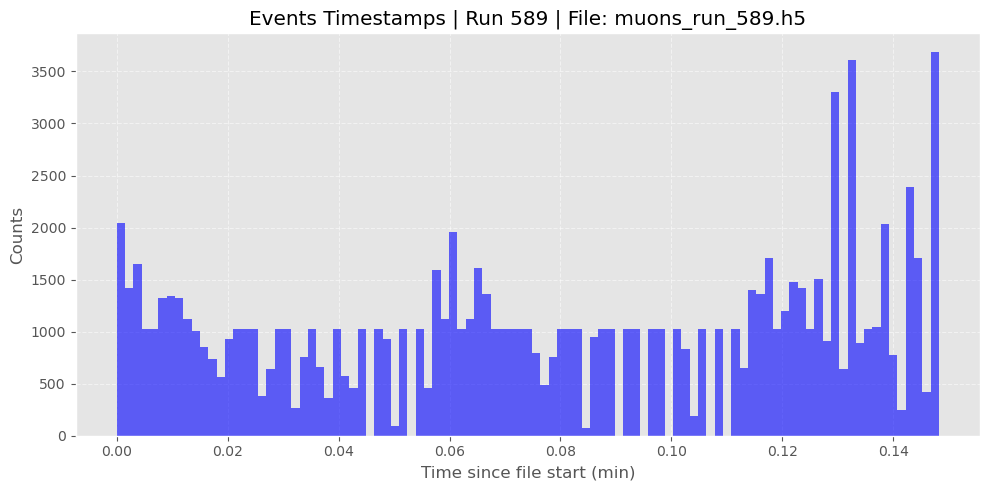

      Analyzed Time : 8.89 seconds
      Events Saved  : 100978
      Events Lost   : 606037 (from lostBuffer)
      Measured Rate : 11352.22 Hz
      Lost Rate     : 68132.32 Hz (+ added by efficiency)
      FINAL RATE    : 79484.54 Hz

[Run 590] Using file: muons_run_590.h5


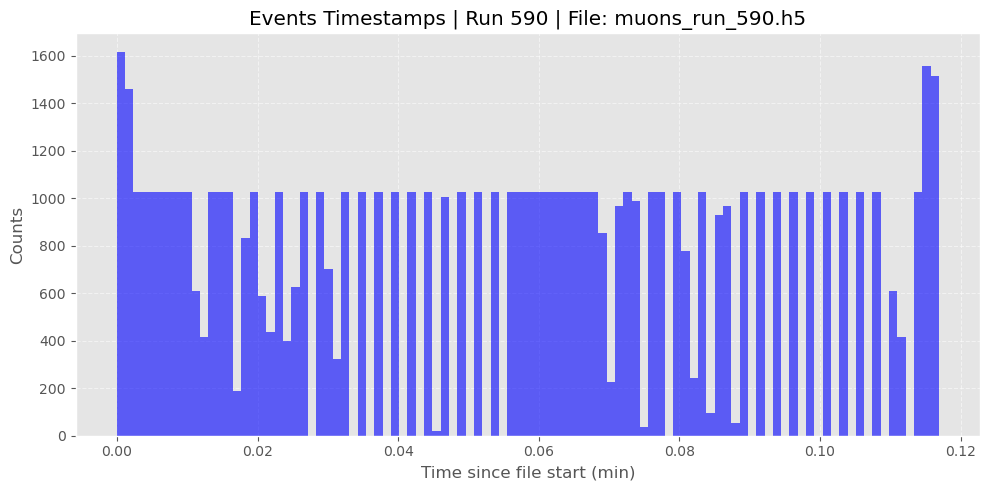

      Analyzed Time : 7.01 seconds
      Events Saved  : 69632
      Events Lost   : 439393 (from lostBuffer)
      Measured Rate : 9927.57 Hz
      Lost Rate     : 62645.14 Hz (+ added by efficiency)
      FINAL RATE    : 72572.71 Hz

[Run 591] Using file: muons_run_591.h5


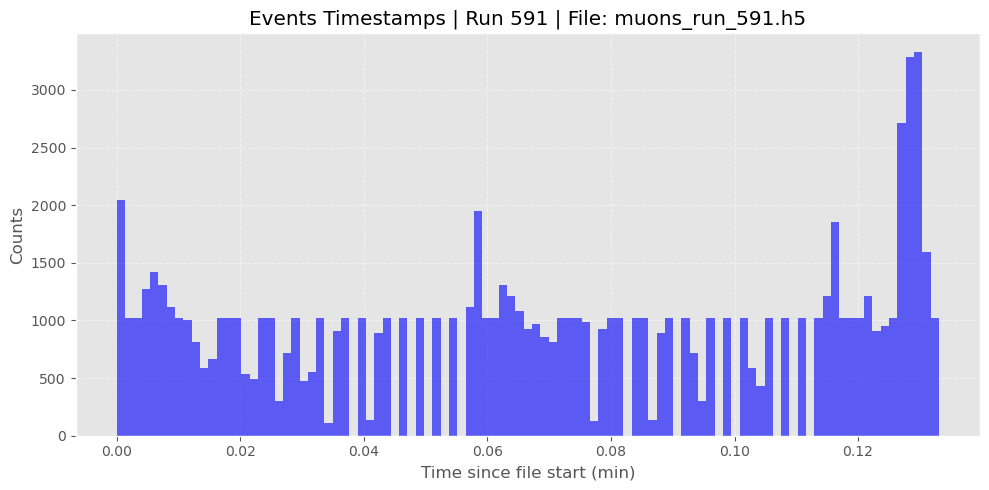

      Analyzed Time : 7.99 seconds
      Events Saved  : 88741
      Events Lost   : 603177 (from lostBuffer)
      Measured Rate : 11113.46 Hz
      Lost Rate     : 75538.76 Hz (+ added by efficiency)
      FINAL RATE    : 86652.22 Hz

[Run 592] Using file: muons_run_592.h5


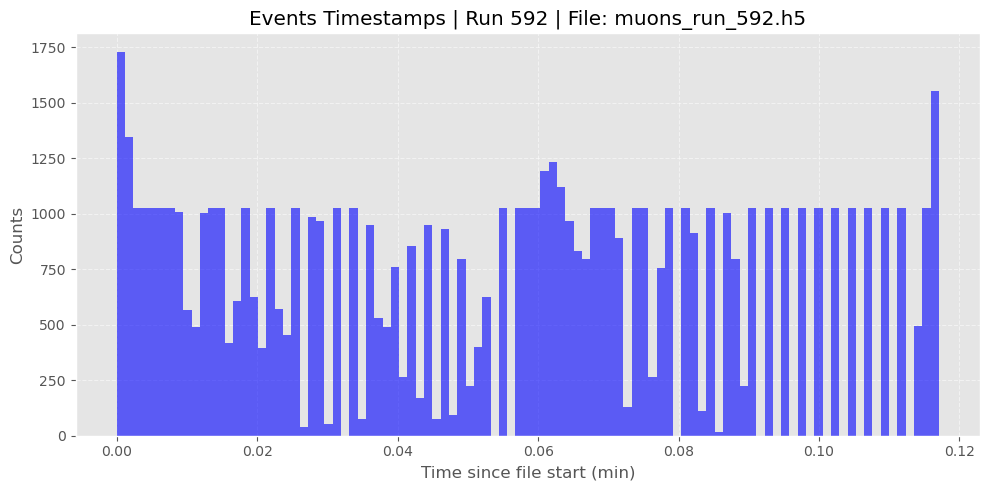

      Analyzed Time : 7.03 seconds
      Events Saved  : 68608
      Events Lost   : 566664 (from lostBuffer)
      Measured Rate : 9766.26 Hz
      Lost Rate     : 80663.91 Hz (+ added by efficiency)
      FINAL RATE    : 90430.18 Hz

[Run 593] Using file: muons_run_593.h5


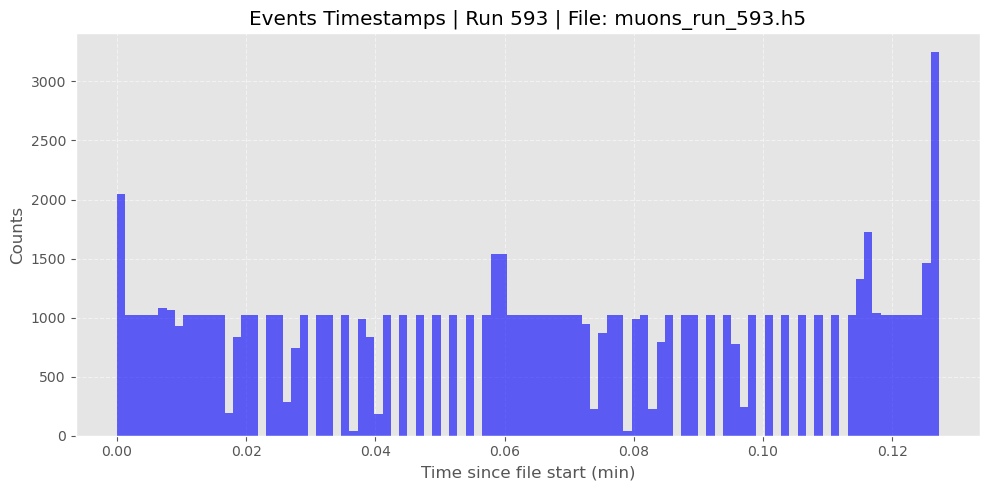

      Analyzed Time : 7.63 seconds
      Events Saved  : 80482
      Events Lost   : 611660 (from lostBuffer)
      Measured Rate : 10545.34 Hz
      Lost Rate     : 80144.13 Hz (+ added by efficiency)
      FINAL RATE    : 90689.47 Hz

[Run 594] Using file: muons_run_594.h5


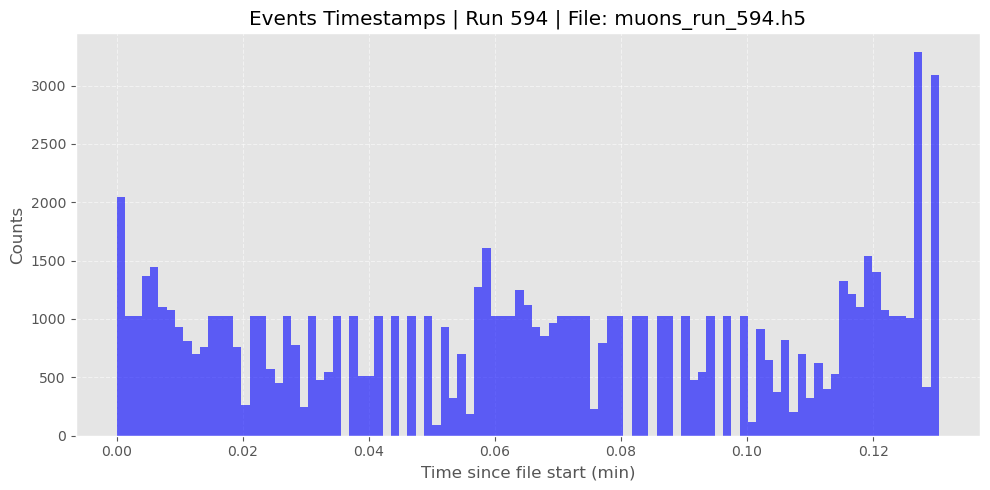

      Analyzed Time : 7.83 seconds
      Events Saved  : 83575
      Events Lost   : 589740 (from lostBuffer)
      Measured Rate : 10679.15 Hz
      Lost Rate     : 75356.50 Hz (+ added by efficiency)
      FINAL RATE    : 86035.65 Hz

[Run 595] Using file: muons_run_595.h5


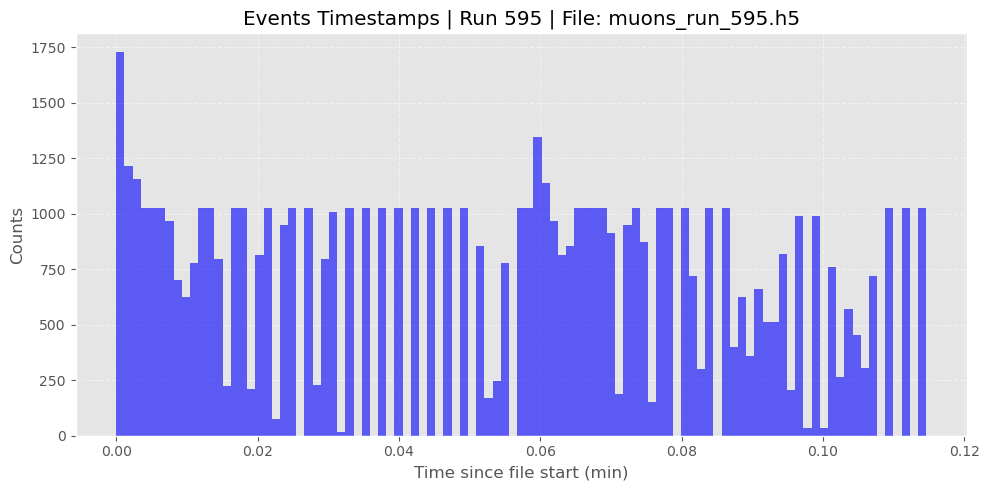

      Analyzed Time : 6.88 seconds
      Events Saved  : 66560
      Events Lost   : 468540 (from lostBuffer)
      Measured Rate : 9678.64 Hz
      Lost Rate     : 68131.45 Hz (+ added by efficiency)
      FINAL RATE    : 77810.09 Hz

[Run 596] Using file: muons_run_596.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 369 events.


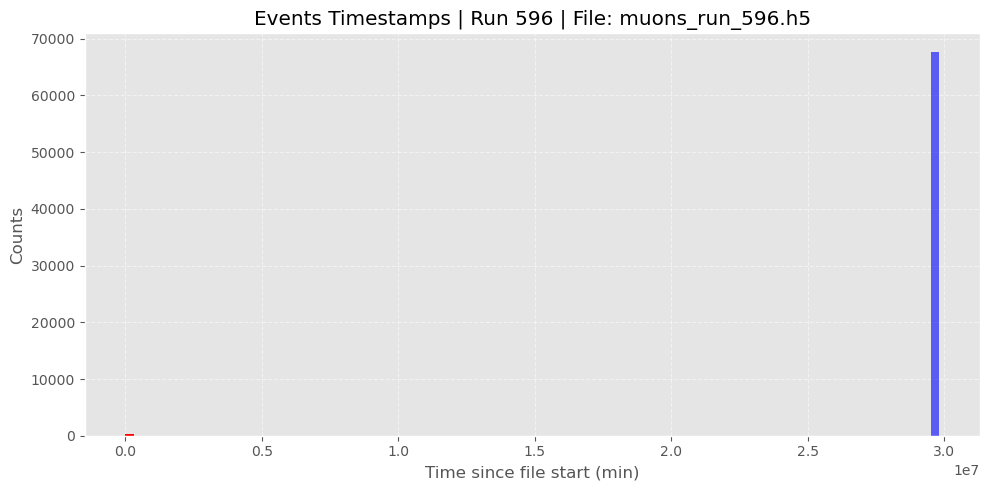

      Analyzed Time : 6.89 seconds
      Events Saved  : 67584
      Events Lost   : 440795 (from lostBuffer)
      Measured Rate : 9813.27 Hz
      Lost Rate     : 64003.92 Hz (+ added by efficiency)
      FINAL RATE    : 73817.19 Hz

[Run 597] Using file: muons_run_597.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 394 events.


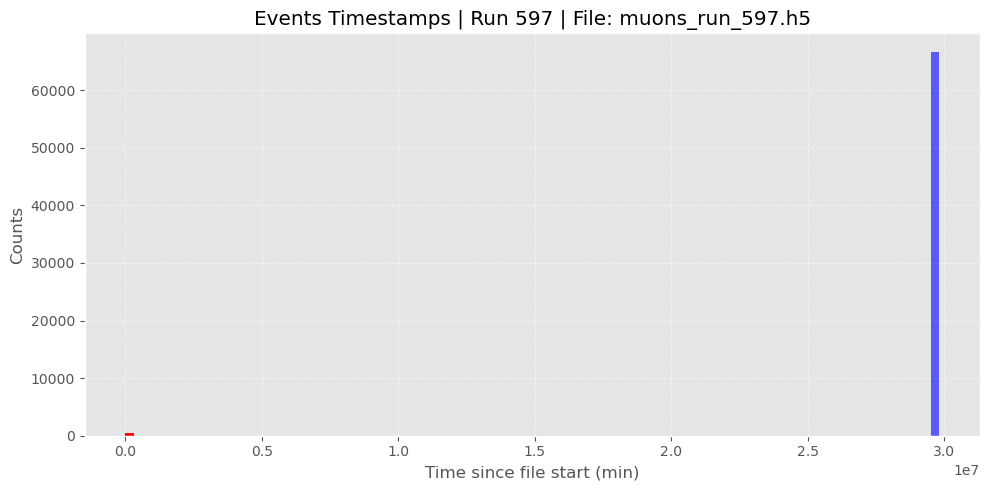

      Analyzed Time : 6.84 seconds
      Events Saved  : 66560
      Events Lost   : 495195 (from lostBuffer)
      Measured Rate : 9730.99 Hz
      Lost Rate     : 72396.93 Hz (+ added by efficiency)
      FINAL RATE    : 82127.92 Hz

[Run 598] Using file: muons_run_598.h5


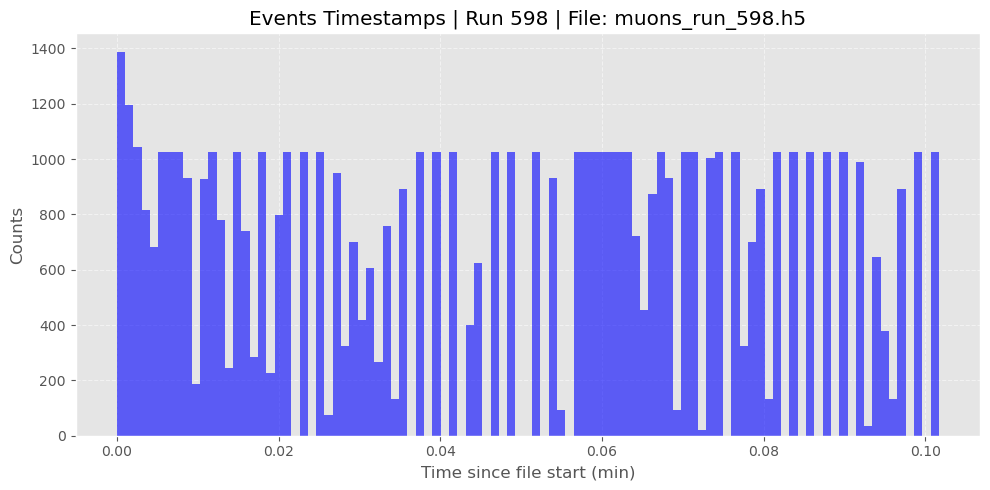

      Analyzed Time : 6.10 seconds
      Events Saved  : 61440
      Events Lost   : 420008 (from lostBuffer)
      Measured Rate : 10070.48 Hz
      Lost Rate     : 68842.48 Hz (+ added by efficiency)
      FINAL RATE    : 78912.97 Hz

[Run 599] Using file: muons_run_599.h5


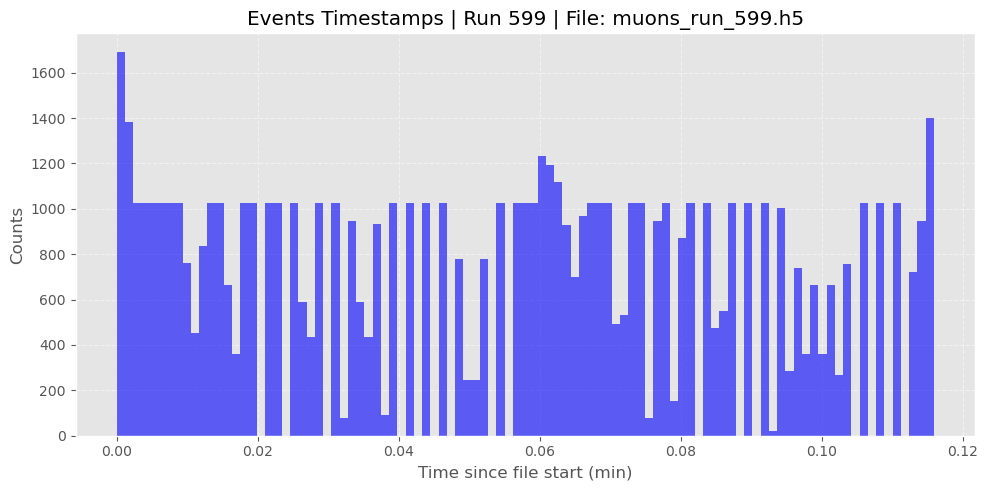

      Analyzed Time : 6.95 seconds
      Events Saved  : 68608
      Events Lost   : 521241 (from lostBuffer)
      Measured Rate : 9865.98 Hz
      Lost Rate     : 74955.57 Hz (+ added by efficiency)
      FINAL RATE    : 84821.54 Hz

[Run 600] Using file: muons_run_600.h5


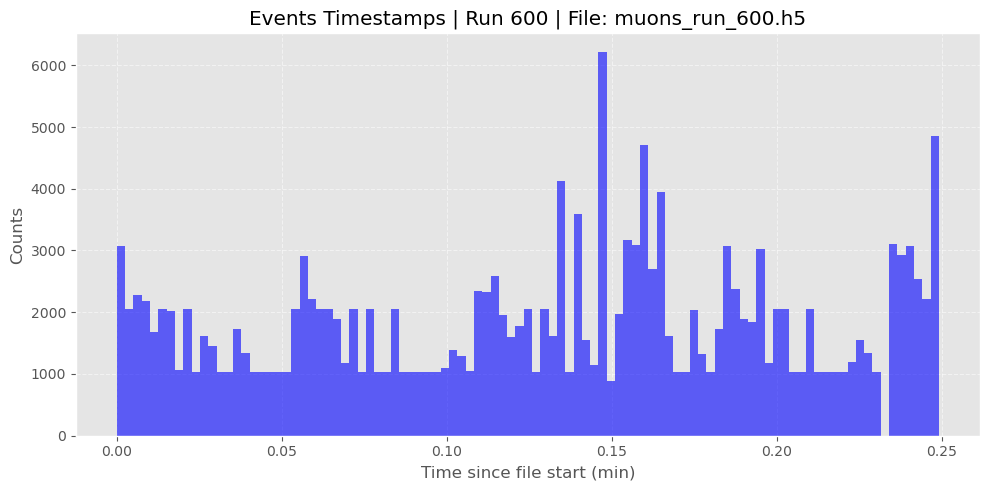

      Analyzed Time : 14.95 seconds
      Events Saved  : 182968
      Events Lost   : 1130535 (from lostBuffer)
      Measured Rate : 12239.48 Hz
      Lost Rate     : 75626.13 Hz (+ added by efficiency)
      FINAL RATE    : 87865.61 Hz

[Run 601] Using file: muons_run_601.h5
      [!] Error: Missing data or required columns in muons_run_601.h5
      Analyzed Time : 0.00 seconds
      Events Saved  : 0
      Events Lost   : 0 (from lostBuffer)
      Measured Rate : 0.00 Hz
      Lost Rate     : 0.00 Hz (+ added by efficiency)
      FINAL RATE    : 0.00 Hz

[Run 602] Using file: muons_run_602.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 341 events.


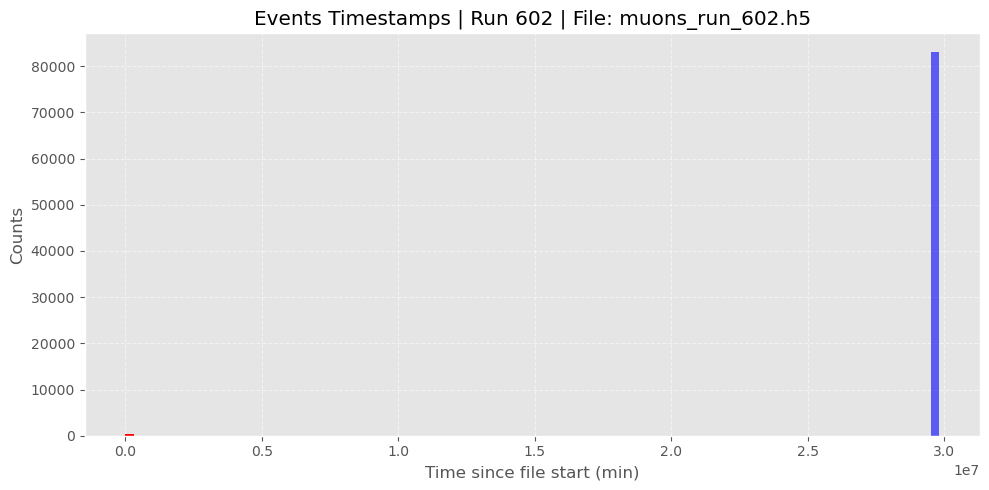

      Analyzed Time : 7.81 seconds
      Events Saved  : 82944
      Events Lost   : 457513 (from lostBuffer)
      Measured Rate : 10624.31 Hz
      Lost Rate     : 58602.92 Hz (+ added by efficiency)
      FINAL RATE    : 69227.23 Hz

[Run 603] Using file: muons_run_603.h5
      [!] Error: Missing data or required columns in muons_run_603.h5
      Analyzed Time : 0.00 seconds
      Events Saved  : 0
      Events Lost   : 0 (from lostBuffer)
      Measured Rate : 0.00 Hz
      Lost Rate     : 0.00 Hz (+ added by efficiency)
      FINAL RATE    : 0.00 Hz

[Run 604] Using file: muons_run_604.h5
      [!] Error: Missing data or required columns in muons_run_604.h5
      Analyzed Time : 0.00 seconds
      Events Saved  : 0
      Events Lost   : 0 (from lostBuffer)
      Measured Rate : 0.00 Hz
      Lost Rate     : 0.00 Hz (+ added by efficiency)
      FINAL RATE    : 0.00 Hz



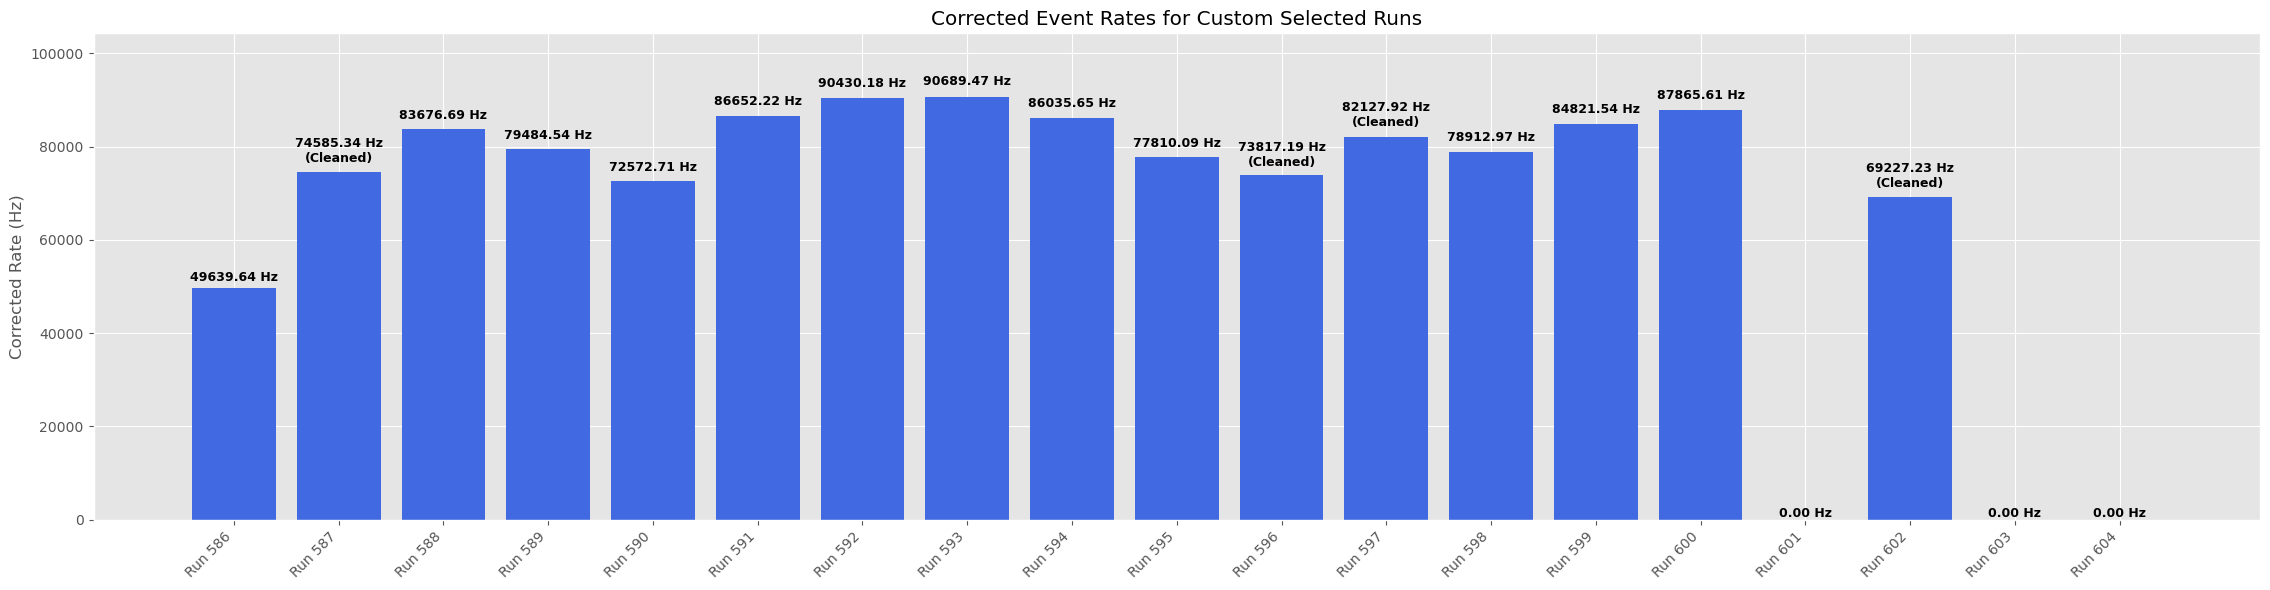

------------------------------------------------------------
Generating charge distribution plots...


/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


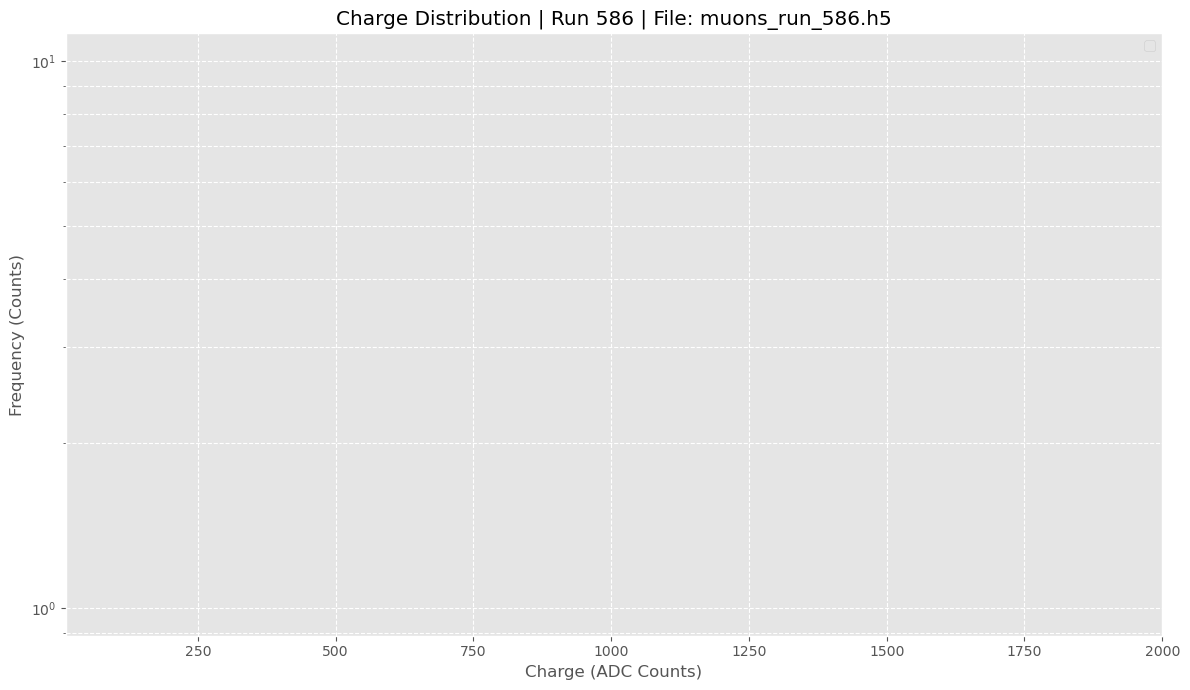

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


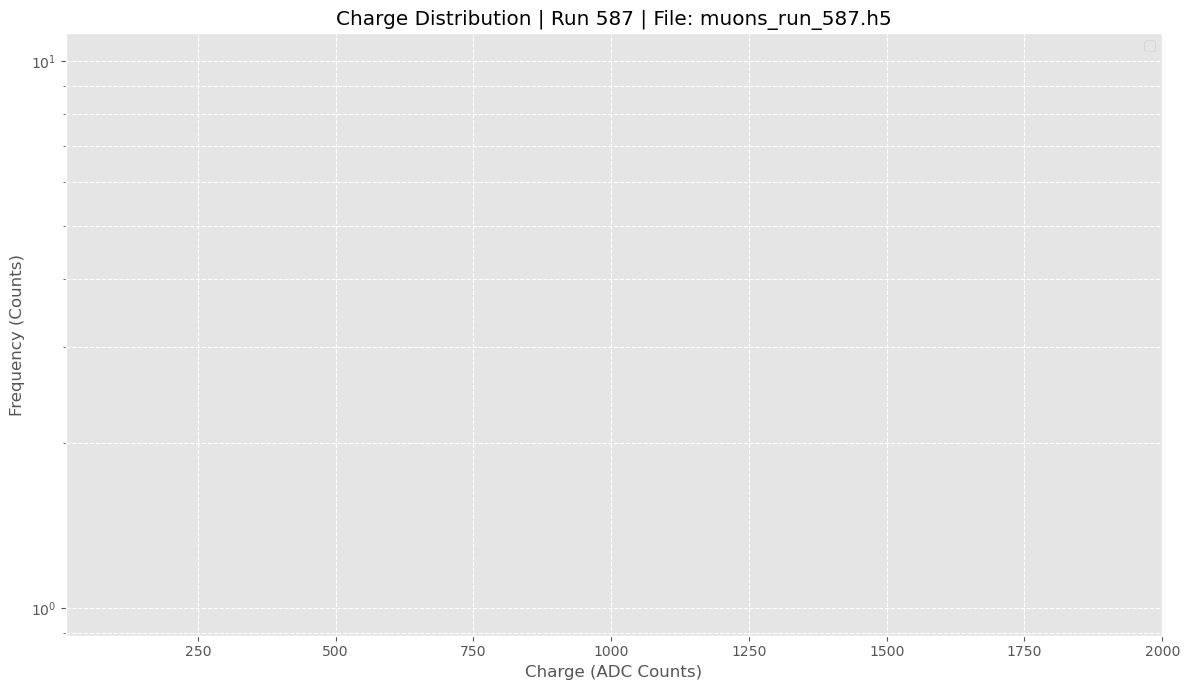

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


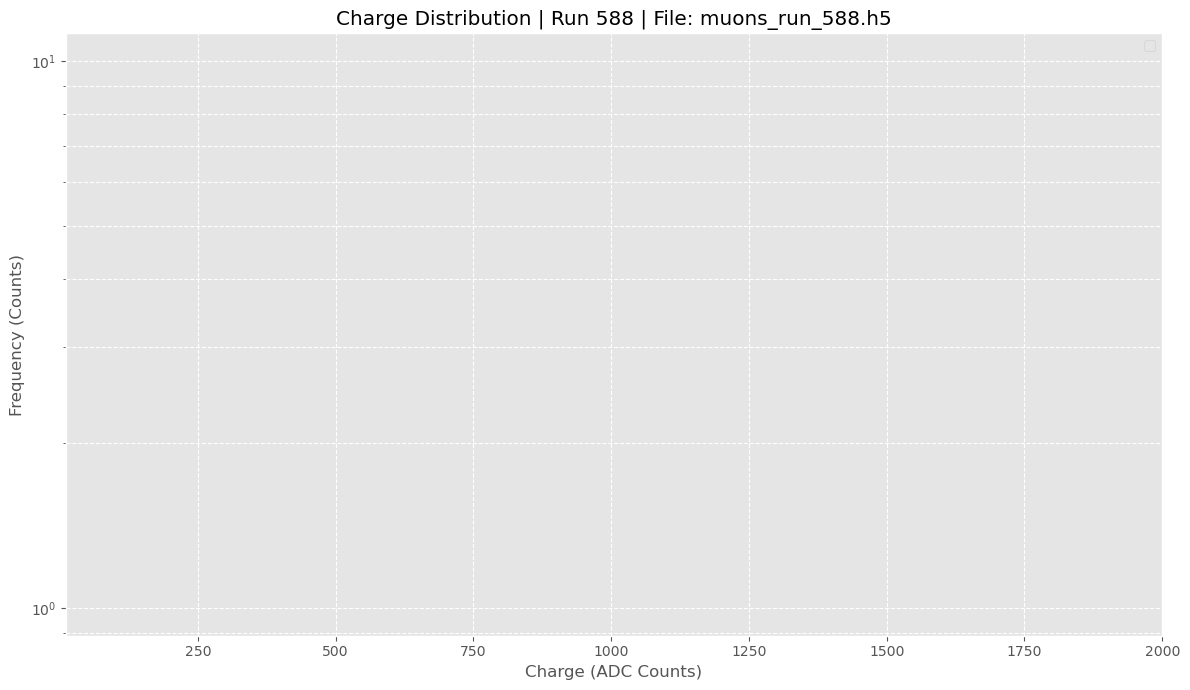

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


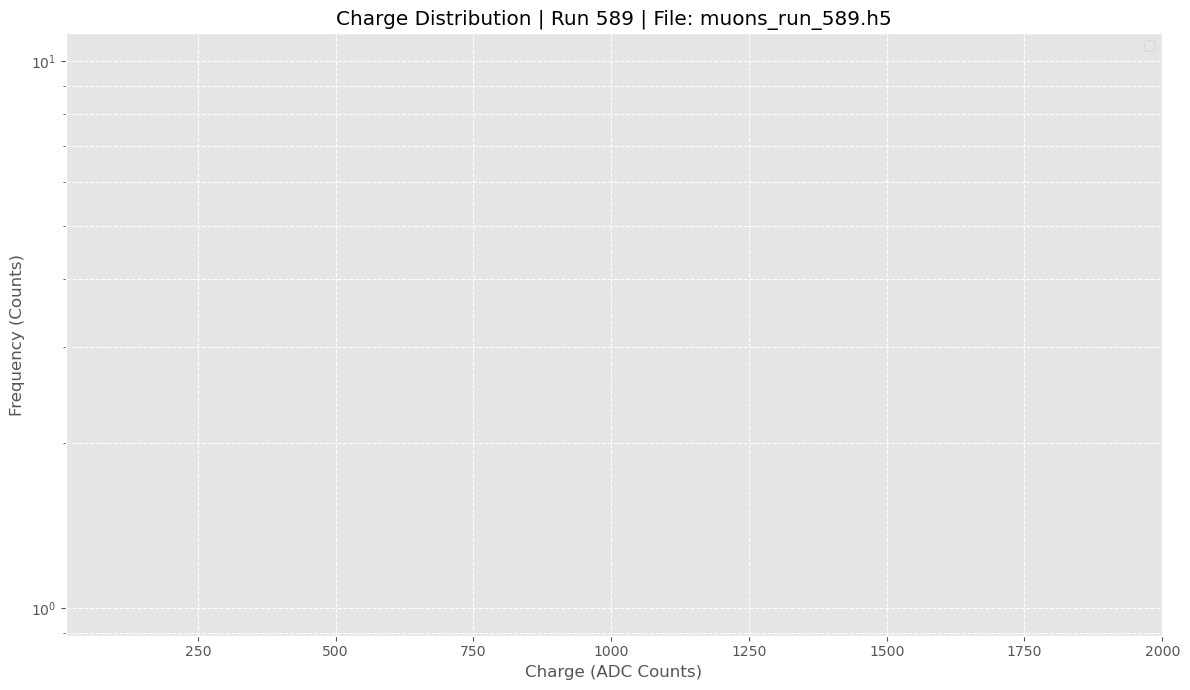

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


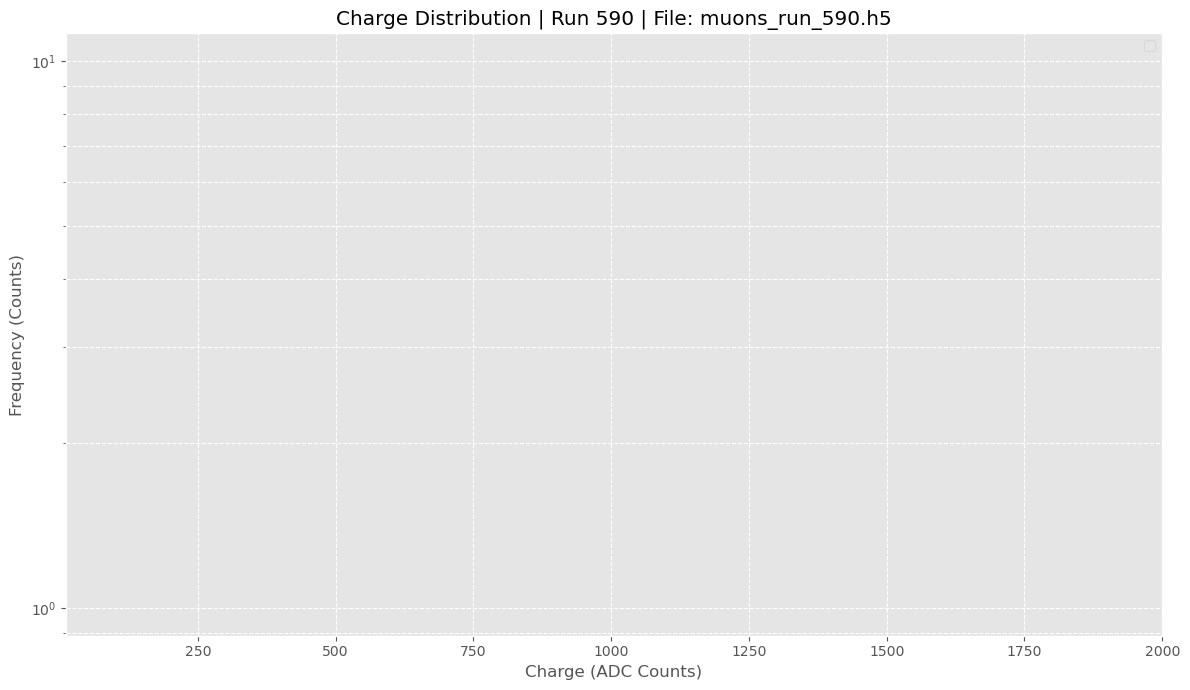

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


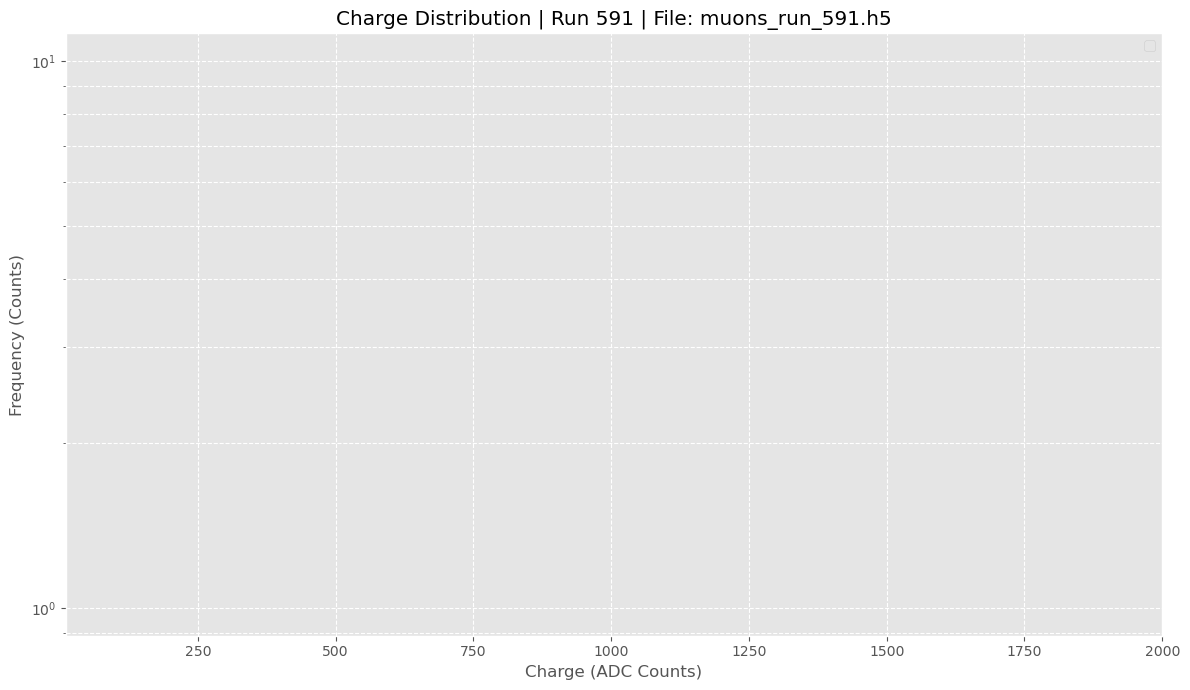

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


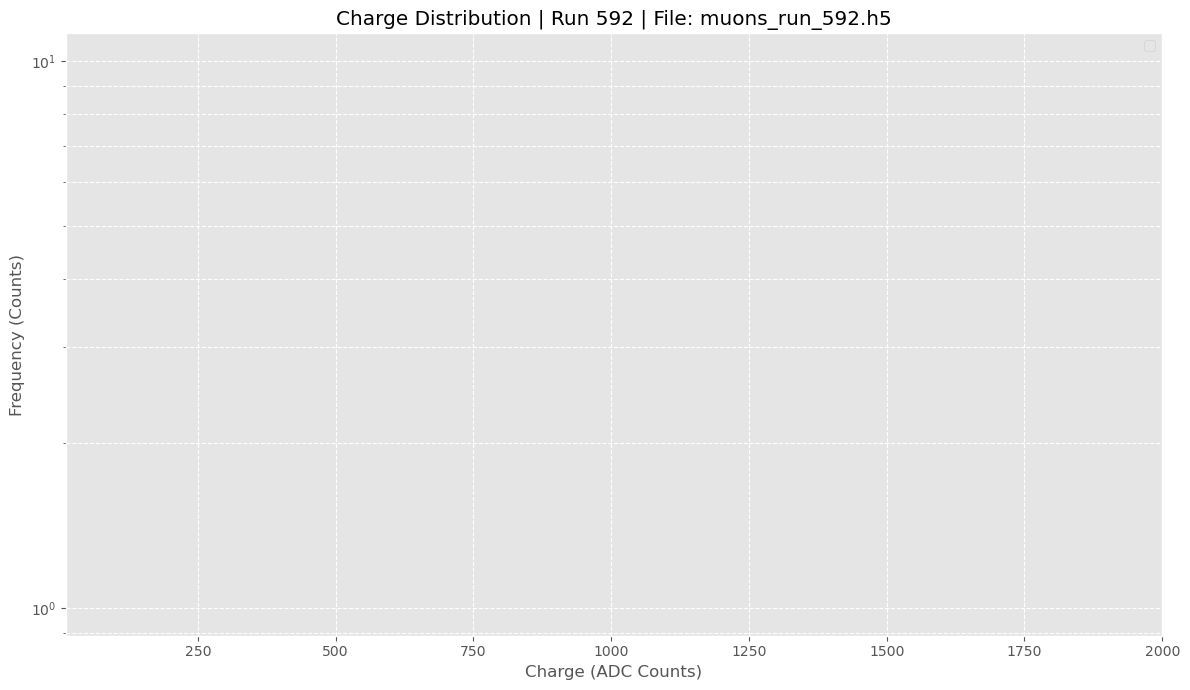

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


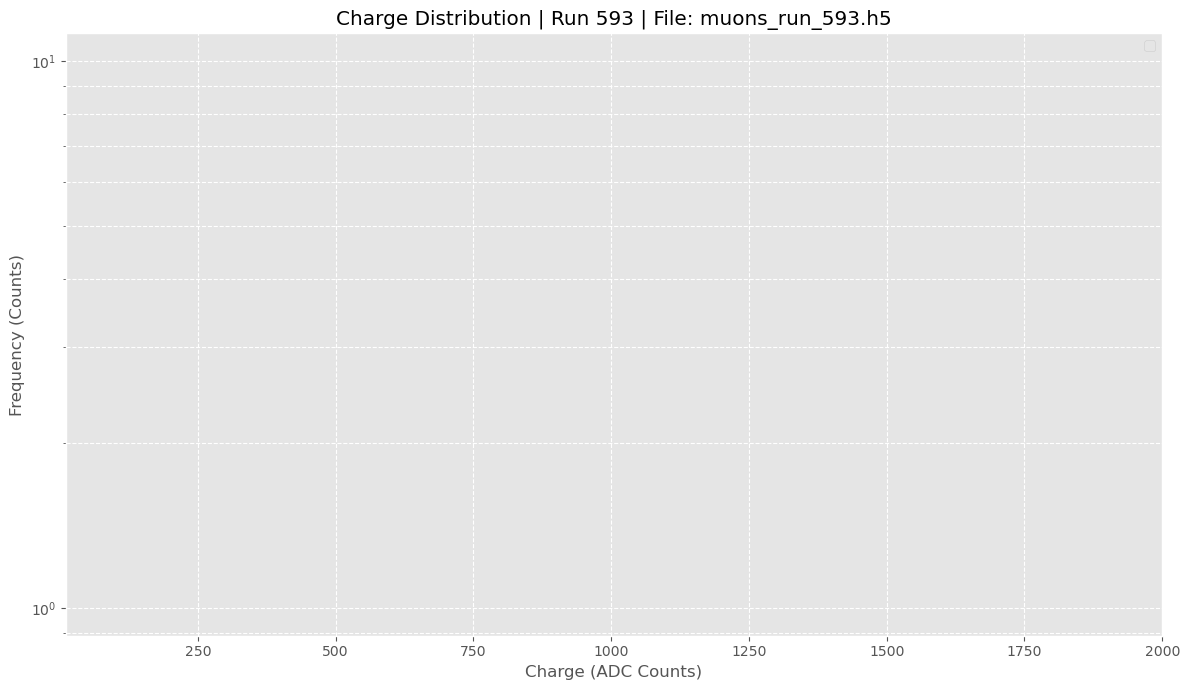

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


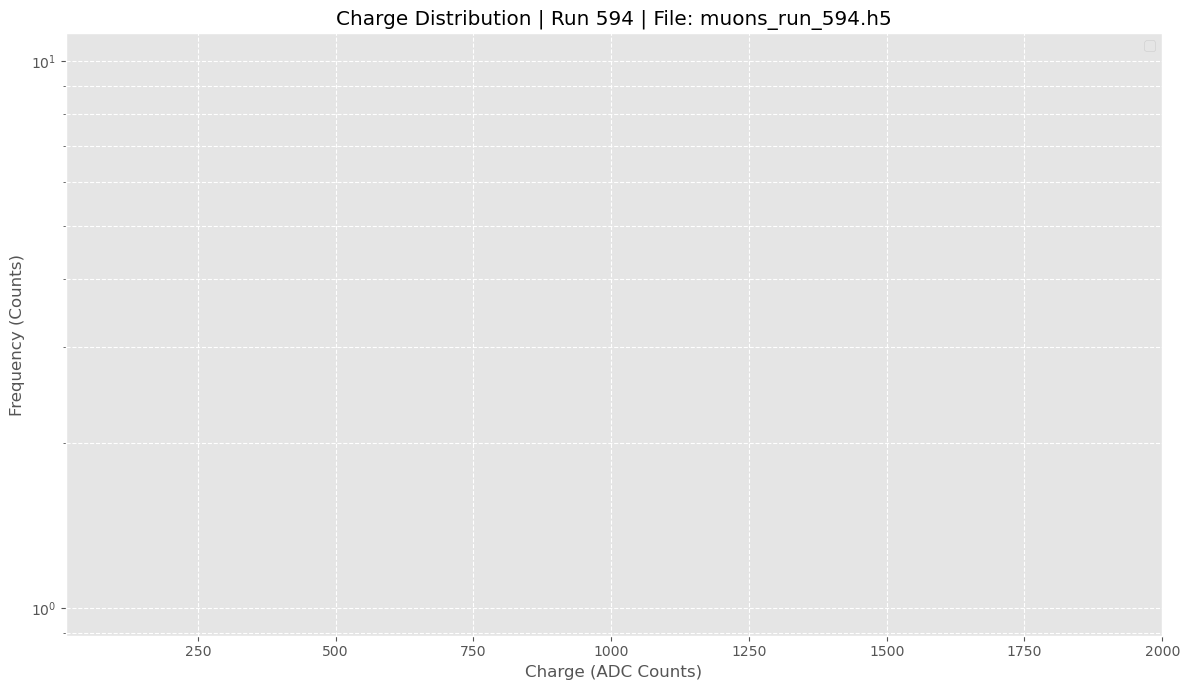

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


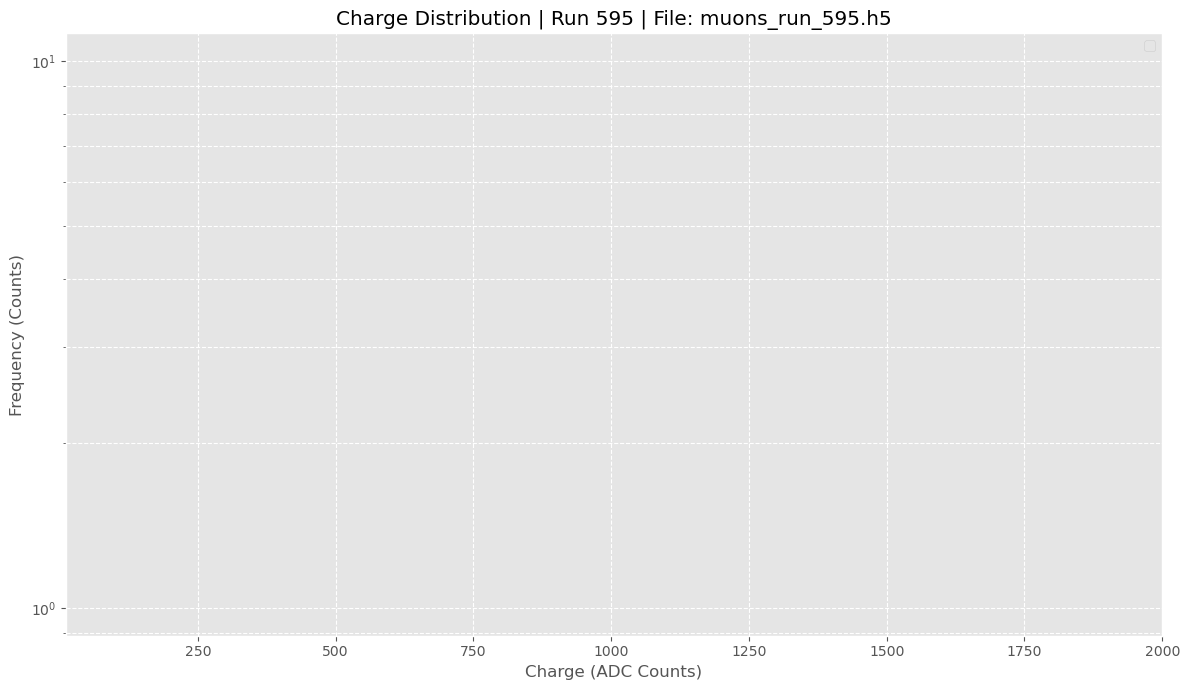

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


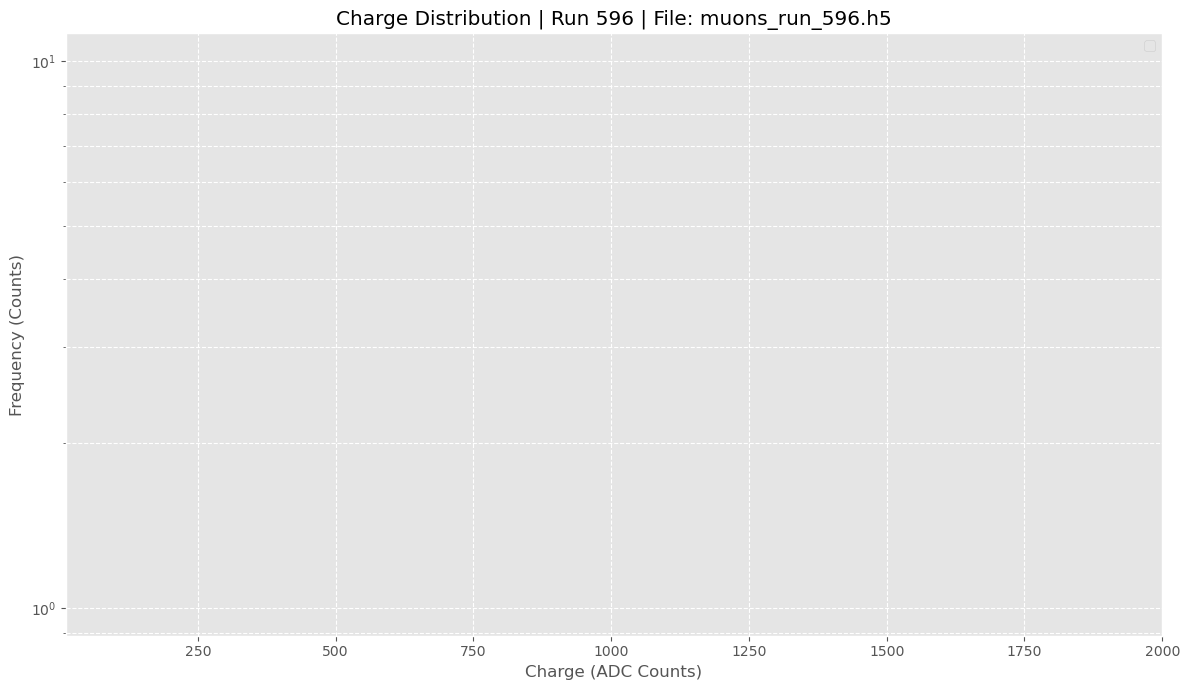

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


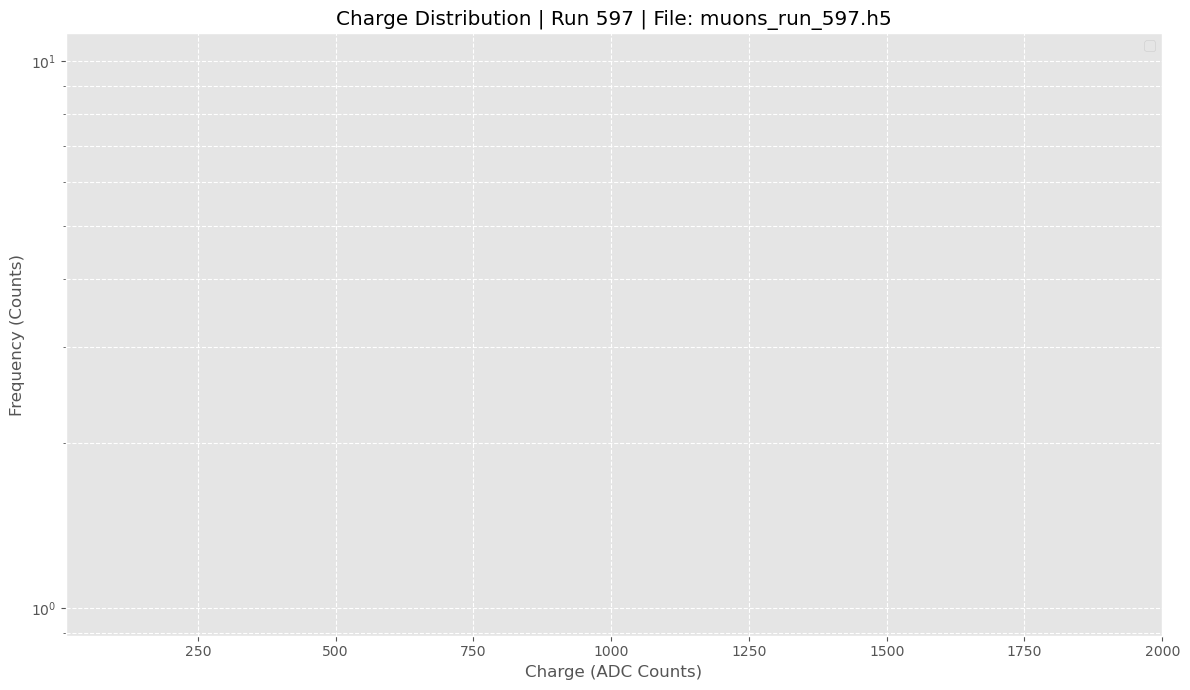

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


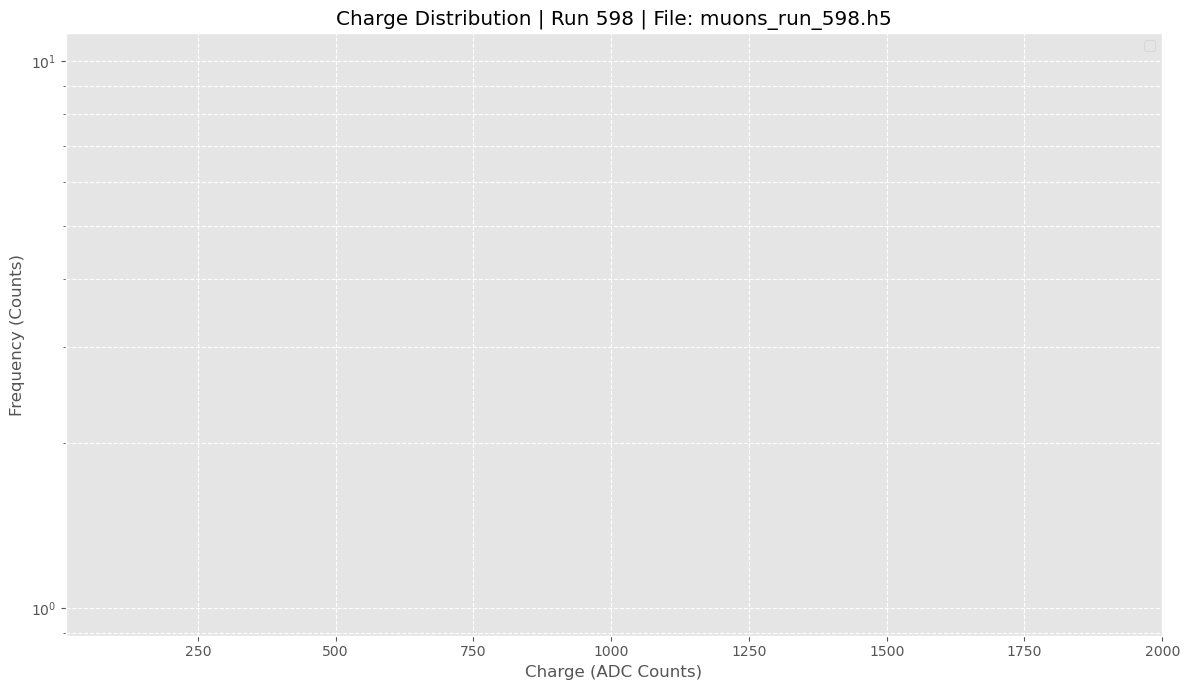

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


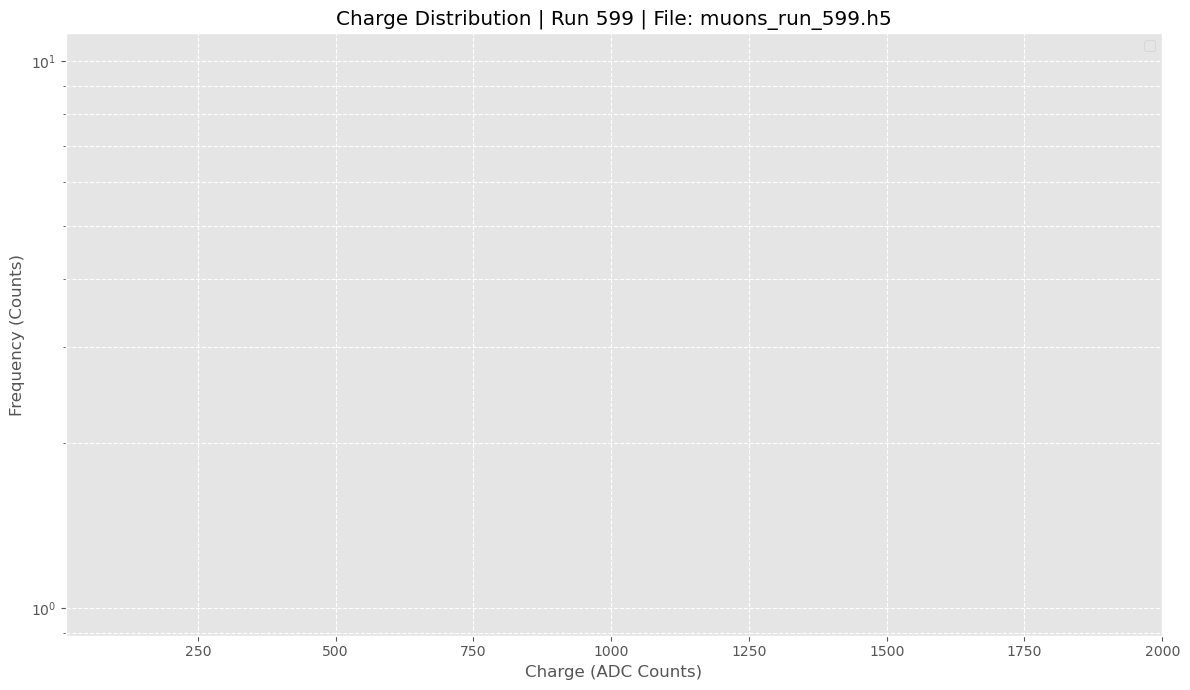

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


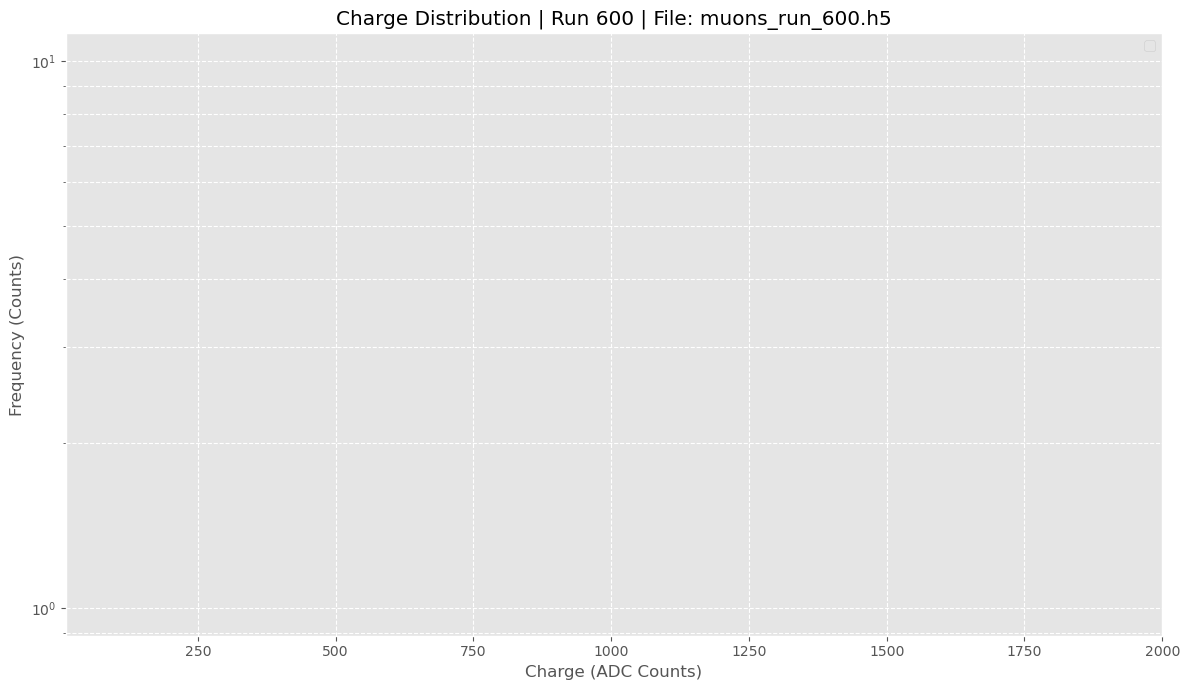

/tmp/ccortesp/ipykernel_2524816/3017156301.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


  [!] Warning: No data or insufficient columns in muons_run_601.h5.


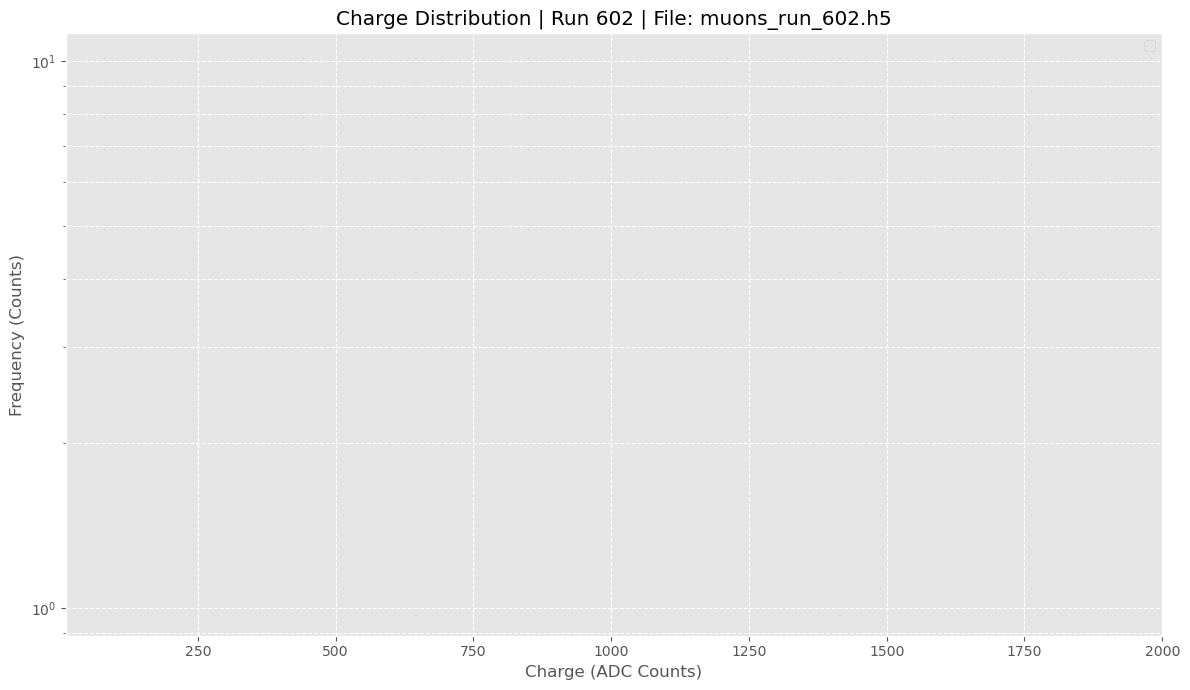

  [!] Warning: No data or insufficient columns in muons_run_603.h5.
  [!] Warning: No data or insufficient columns in muons_run_604.h5.

--- Custom Analysis Complete ---



In [ ]:
analyze_bars(BASE_PATH, selected_runs=[586, 587, 588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 600, 601, 602, 603, 604])

### Checking A1, A2 Bars


--- Custom Run Analysis Mode ---
Found 1 files to analyze.
------------------------------------------------------------
[Run 619] Using file: muons_run_619.h5


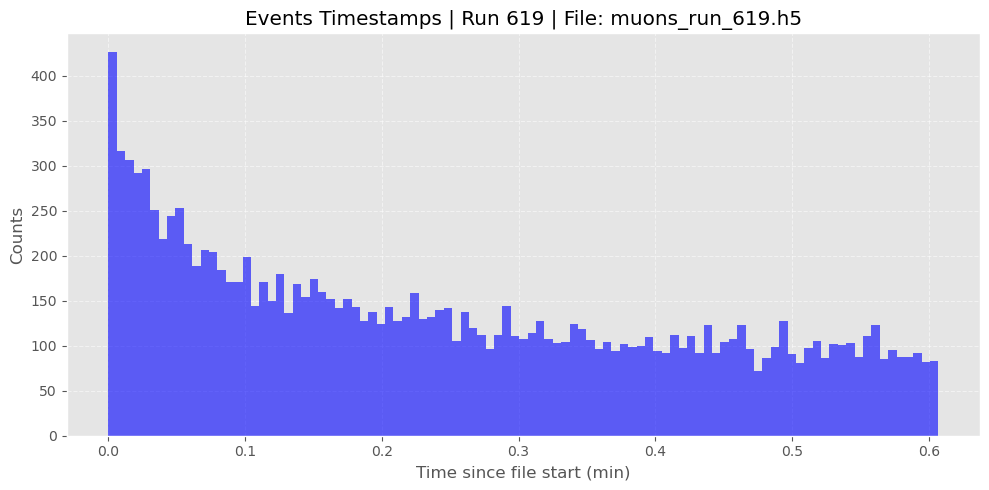

      Analyzed Time : 36.42 seconds
      Events Saved  : 13647
      Events Lost   : 5 (from lostBuffer)
      Measured Rate : 374.68 Hz
      Lost Rate     : 0.14 Hz (+ added by efficiency)
      FINAL RATE    : 374.82 Hz



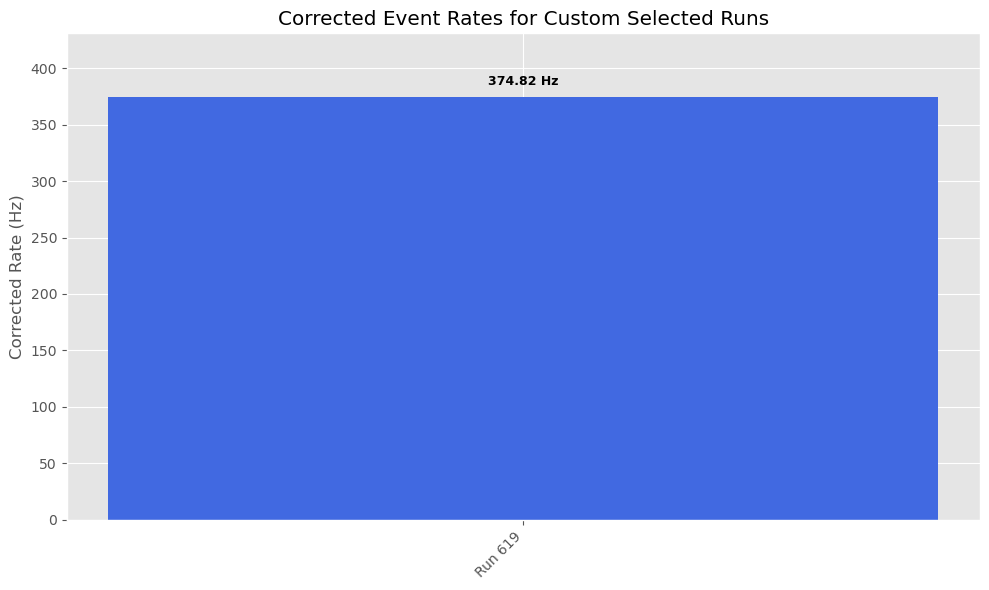

------------------------------------------------------------
Generating charge distribution plots...


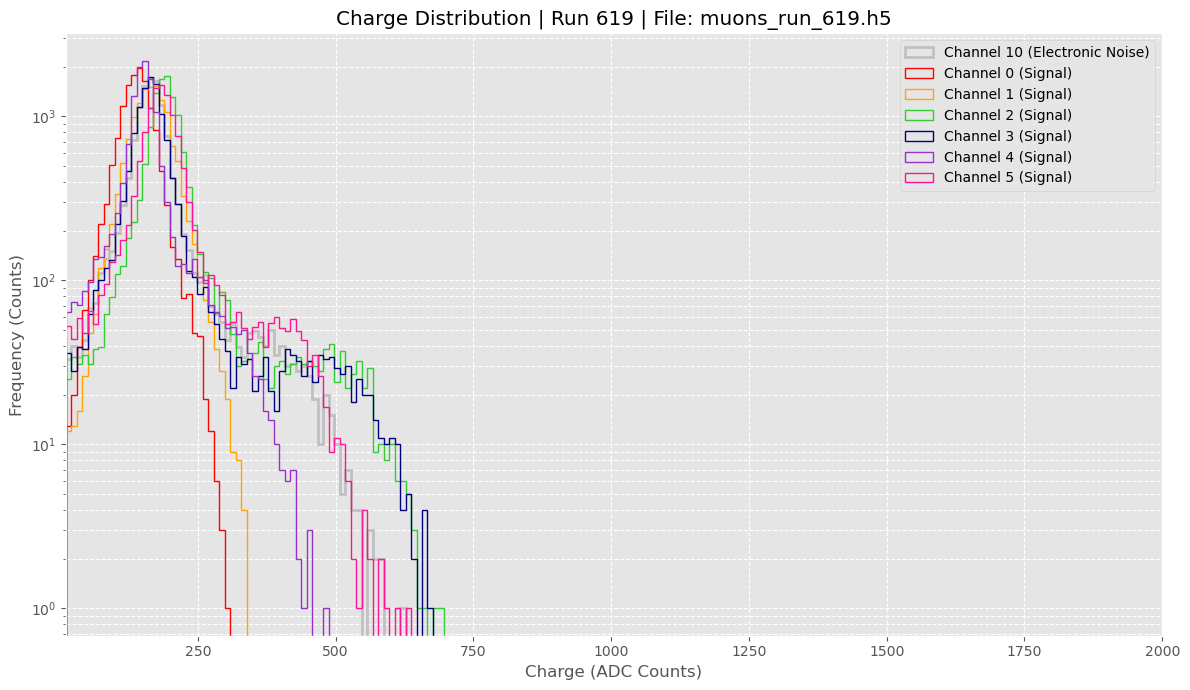


--- Custom Analysis Complete ---



In [18]:
analyze_bars(BASE_PATH, selected_runs=[619], signal_channels=[0, 1, 2, 3, 4, 5], ref_channels=[10], plot_range=(10, 2000), bins=200, log_scale=True)

# Module L


--- Custom Run Analysis Mode ---
Found 5 files to analyze.
------------------------------------------------------------
[Run 625] Using file: muons_run_625.h5


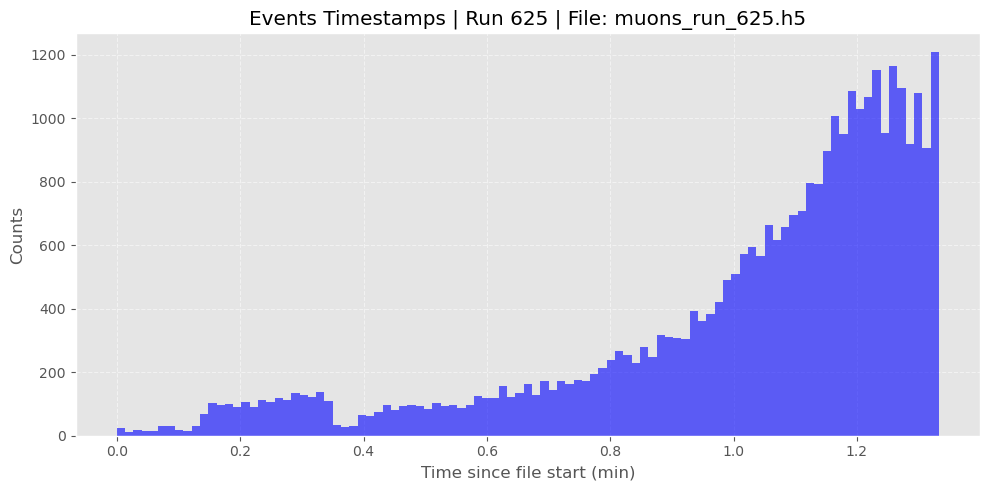

      Analyzed Time : 79.98 seconds
      Events Saved  : 32239
      Events Lost   : 437838 (from lostBuffer)
      Measured Rate : 403.09 Hz
      Lost Rate     : 5474.34 Hz (+ added by efficiency)
      FINAL RATE    : 5877.43 Hz

[Run 626] Using file: muons_run_626.h5


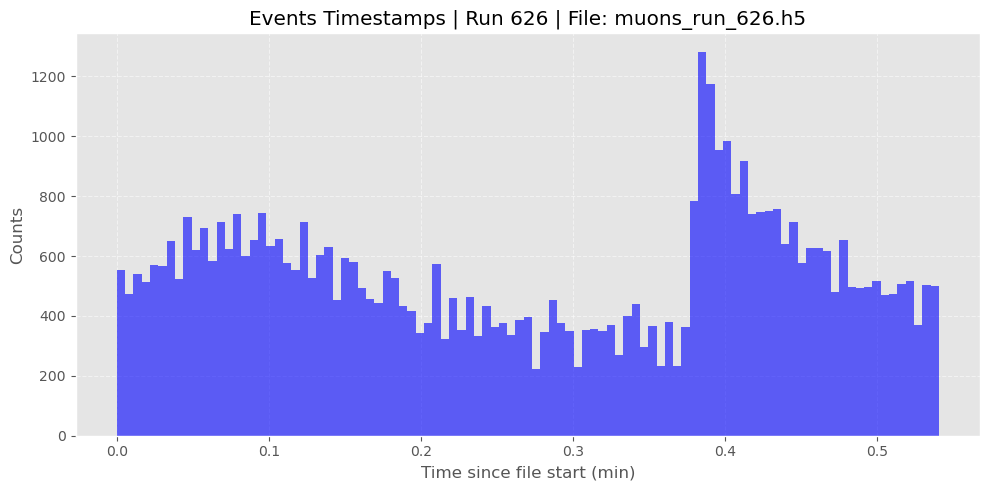

      Analyzed Time : 32.44 seconds
      Events Saved  : 53027
      Events Lost   : 692035 (from lostBuffer)
      Measured Rate : 1634.67 Hz
      Lost Rate     : 21333.43 Hz (+ added by efficiency)
      FINAL RATE    : 22968.09 Hz

[Run 630] Using file: muons_run_630.h5


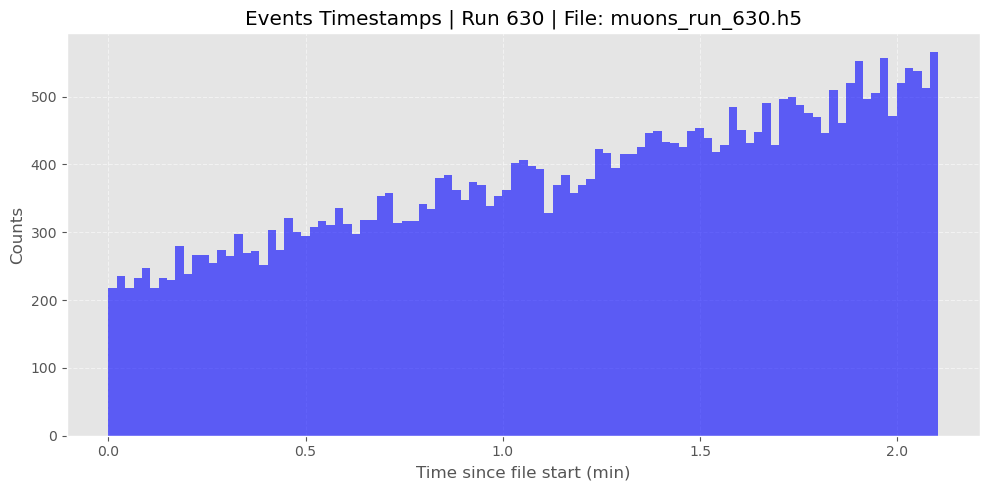

      Analyzed Time : 126.28 seconds
      Events Saved  : 37399
      Events Lost   : 532757 (from lostBuffer)
      Measured Rate : 296.17 Hz
      Lost Rate     : 4219.02 Hz (+ added by efficiency)
      FINAL RATE    : 4515.19 Hz

[Run 631] Using file: muons_run_631.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 16 events.


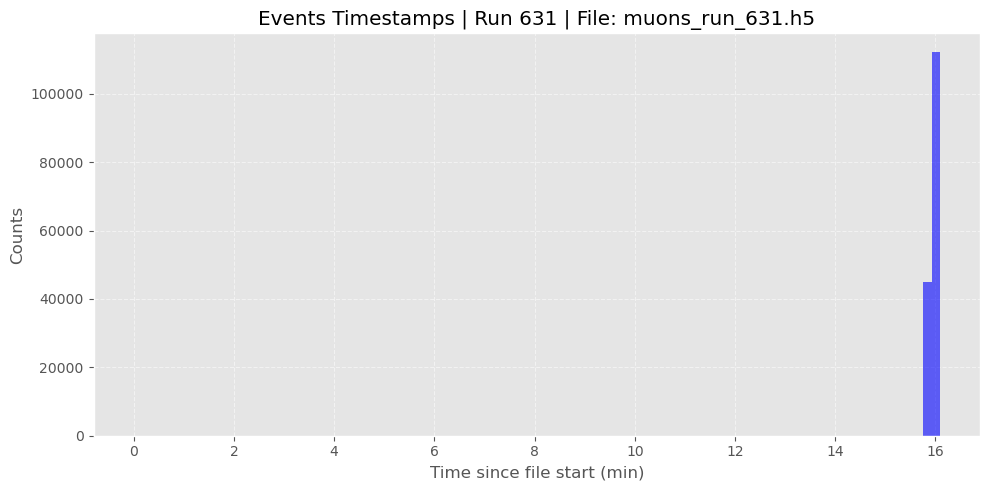

      Analyzed Time : 14.40 seconds
      Events Saved  : 157148
      Events Lost   : 2106523 (from lostBuffer)
      Measured Rate : 10914.57 Hz
      Lost Rate     : 146306.64 Hz (+ added by efficiency)
      FINAL RATE    : 157221.21 Hz

[Run 632] Using file: muons_run_632.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 342 events.


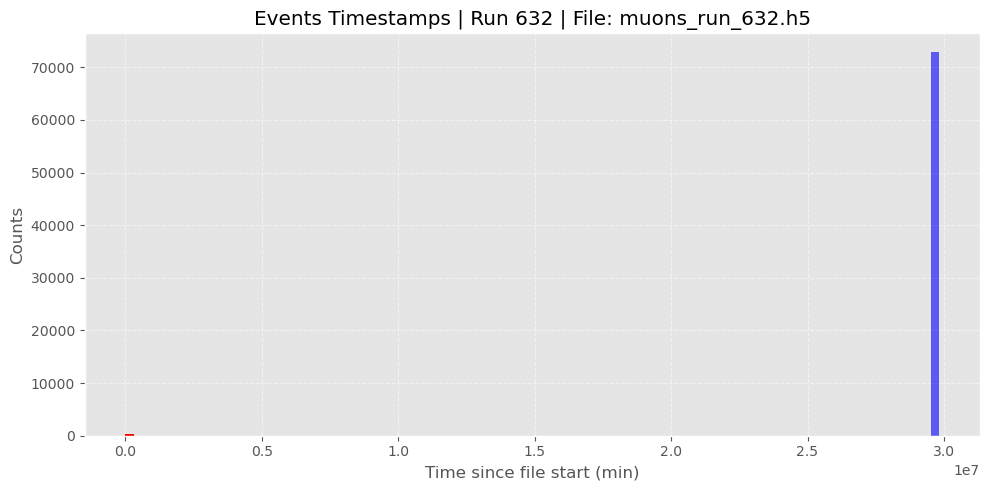

      Analyzed Time : 10.41 seconds
      Events Saved  : 72827
      Events Lost   : 1034380 (from lostBuffer)
      Measured Rate : 6996.54 Hz
      Lost Rate     : 99373.62 Hz (+ added by efficiency)
      FINAL RATE    : 106370.16 Hz



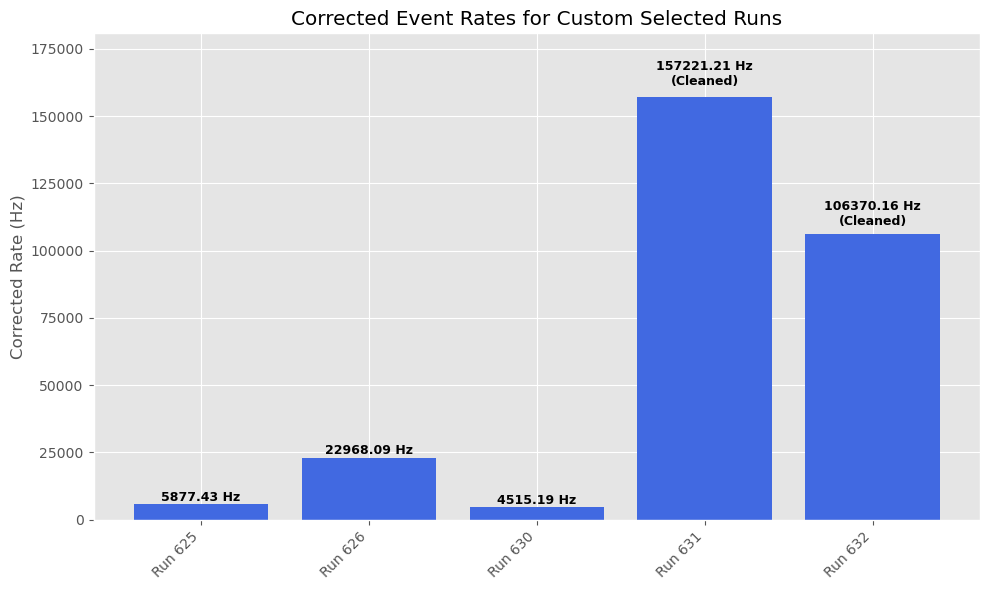

------------------------------------------------------------
Generating charge distribution plots...

--- Module Commissioning Report: muons_run_625.h5 (32239 events, 32 readout channels) ---

[✓] ACTIVE BARS (Cosmic Scintillation)  [0]: []

[!] DARK NOISE (SiPM biased, NO light) [17]: [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
  • Ch 0: Ped. Median: 205.00 ADC | Ped. Sigma: 17.00 ADC | SNR: 0.76 | Max. Charge: 1311 ADC | P99 Charge: 314.00 ADC | Signal Hits: 3
  • Ch 1: Ped. Median: 219.00 ADC | Ped. Sigma: 16.00 ADC | SNR: 0.81 | Max. Charge: 1213 ADC | P99 Charge: 403.72 ADC | Signal Hits: 4
  • Ch 2: Ped. Median: 214.00 ADC | Ped. Sigma: 16.00 ADC | SNR: 0.75 | Max. Charge: 1210 ADC | P99 Charge: 325.00 ADC | Signal Hits: 4
  • Ch 3: Ped. Median: 215.00 ADC | Ped. Sigma: 16.00 ADC | SNR: 0.81 | Max. Charge: 505 ADC | P99 Charge: 323.00 ADC | Signal Hits: 0
  • Ch 4: Ped. Median: 196.00 ADC | Ped. Sigma: 16.00 ADC | SNR: 0.81 | Max. Charge: 691 ADC | P99 Charge: 305

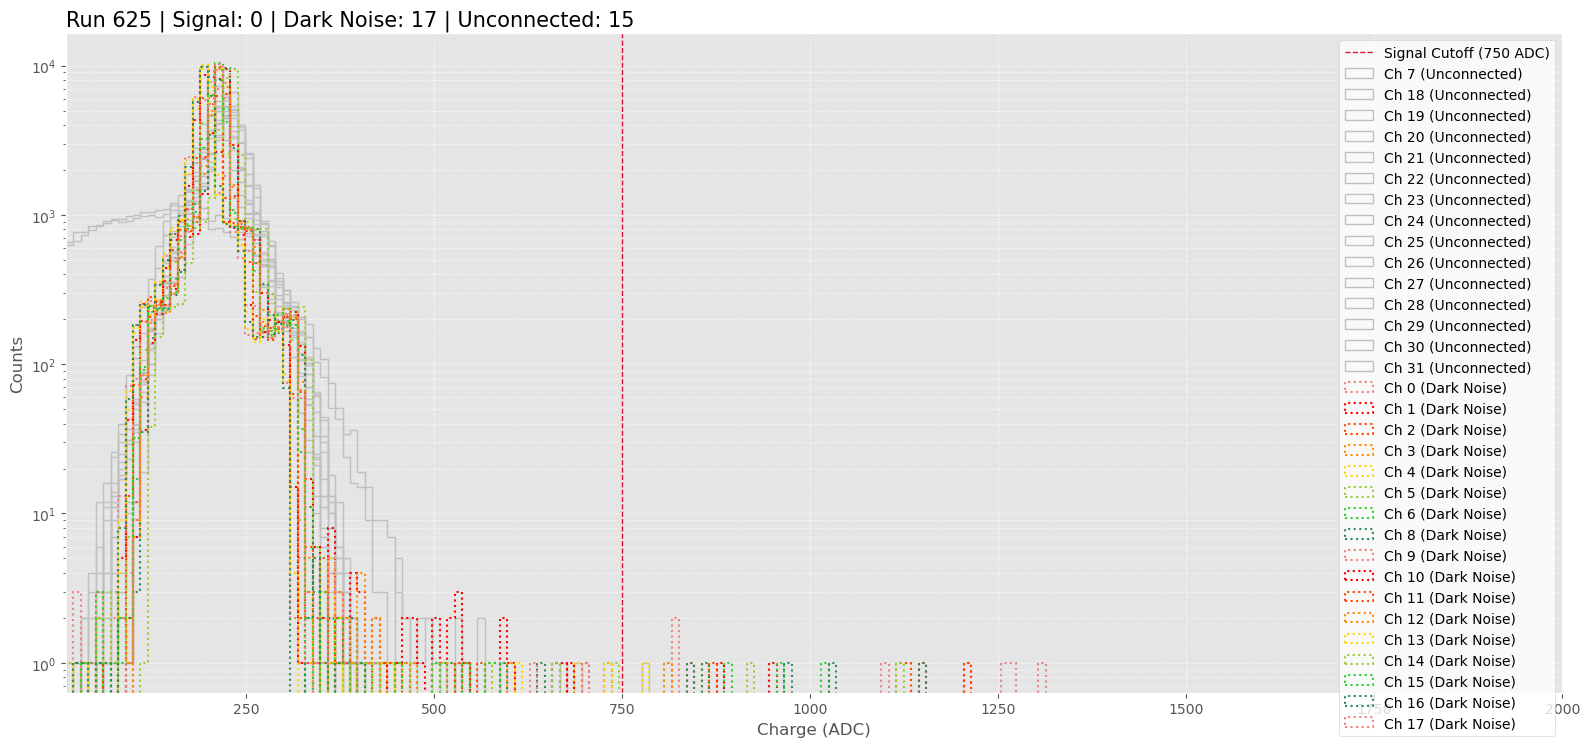


--- Module Commissioning Report: muons_run_626.h5 (53027 events, 32 readout channels) ---

[✓] ACTIVE BARS (Cosmic Scintillation)  [0]: []

[!] DARK NOISE (SiPM biased, NO light) [17]: [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
  • Ch 0: Ped. Median: 206.00 ADC | Ped. Sigma: 16.00 ADC | SNR: 0.88 | Max. Charge: 402 ADC | P99 Charge: 313.00 ADC | Signal Hits: 0
  • Ch 1: Ped. Median: 219.00 ADC | Ped. Sigma: 16.00 ADC | SNR: 0.75 | Max. Charge: 597 ADC | P99 Charge: 325.00 ADC | Signal Hits: 0
  • Ch 2: Ped. Median: 214.00 ADC | Ped. Sigma: 16.00 ADC | SNR: 0.81 | Max. Charge: 641 ADC | P99 Charge: 320.00 ADC | Signal Hits: 0
  • Ch 3: Ped. Median: 215.00 ADC | Ped. Sigma: 16.00 ADC | SNR: 0.81 | Max. Charge: 405 ADC | P99 Charge: 321.00 ADC | Signal Hits: 0
  • Ch 4: Ped. Median: 196.00 ADC | Ped. Sigma: 16.00 ADC | SNR: 0.81 | Max. Charge: 427 ADC | P99 Charge: 302.00 ADC | Signal Hits: 0
  • Ch 5: Ped. Median: 208.00 ADC | Ped. Sigma: 16.00 ADC | SNR: 0.81 | Max. Ch

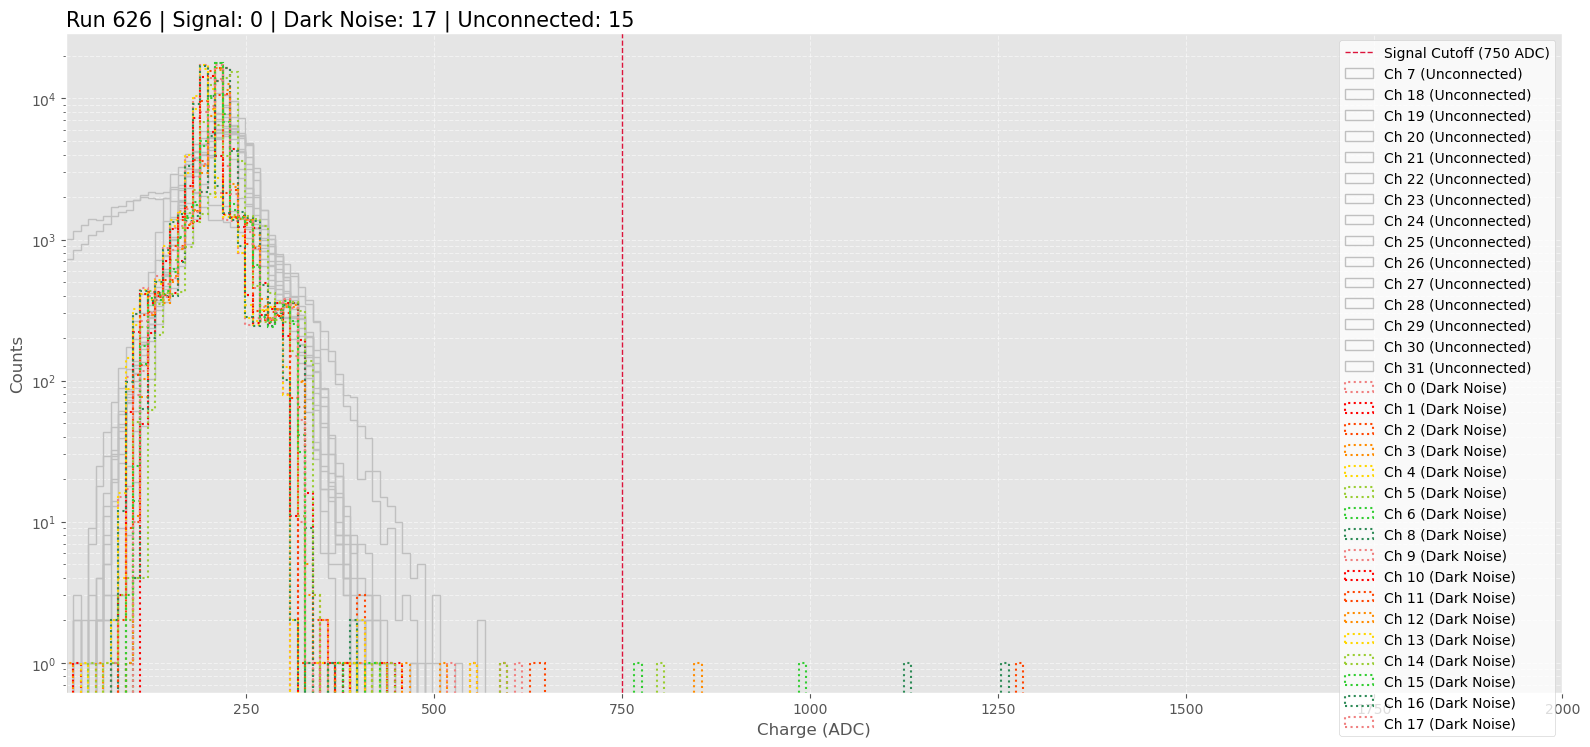


--- Module Commissioning Report: muons_run_630.h5 (37399 events, 32 readout channels) ---

[✓] ACTIVE BARS (Cosmic Scintillation)  [0]: []

[!] DARK NOISE (SiPM biased, NO light) [21]: [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 23, 24, 25]
  • Ch 0: Ped. Median: 206.00 ADC | Ped. Sigma: 16.00 ADC | SNR: 0.75 | Max. Charge: 1814 ADC | P99 Charge: 316.00 ADC | Signal Hits: 5
  • Ch 1: Ped. Median: 219.00 ADC | Ped. Sigma: 15.00 ADC | SNR: 0.80 | Max. Charge: 1453 ADC | P99 Charge: 330.00 ADC | Signal Hits: 7
  • Ch 2: Ped. Median: 214.00 ADC | Ped. Sigma: 15.00 ADC | SNR: 0.80 | Max. Charge: 1481 ADC | P99 Charge: 324.00 ADC | Signal Hits: 7
  • Ch 3: Ped. Median: 216.00 ADC | Ped. Sigma: 16.00 ADC | SNR: 0.75 | Max. Charge: 1488 ADC | P99 Charge: 325.00 ADC | Signal Hits: 3
  • Ch 4: Ped. Median: 197.00 ADC | Ped. Sigma: 16.00 ADC | SNR: 0.75 | Max. Charge: 1101 ADC | P99 Charge: 304.00 ADC | Signal Hits: 4
  • Ch 5: Ped. Median: 209.00 ADC | Ped. Sigma: 16.00 ADC 

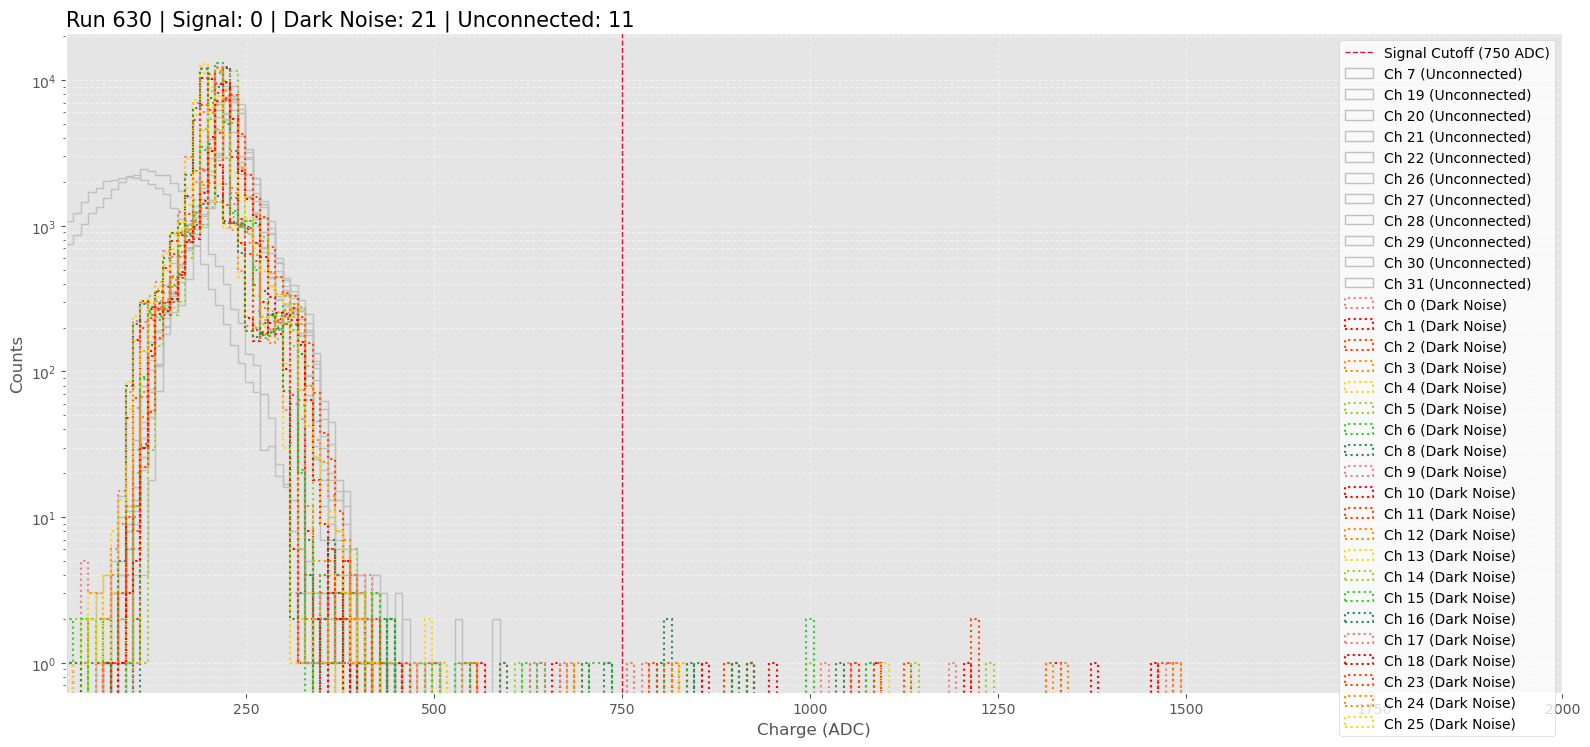


--- Module Commissioning Report: muons_run_631.h5 (157164 events, 32 readout channels) ---

[✓] ACTIVE BARS (Cosmic Scintillation)  [19]: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 31]
  • Ch 0: Ped. Median: 206.00 ADC | Ped. Sigma: 40.00 ADC | SNR: 1.60 | Max. Charge: 1096 ADC | P99 Charge: 928.00 ADC | Signal Hits: 2356
  • Ch 1: Ped. Median: 218.00 ADC | Ped. Sigma: 42.00 ADC | SNR: 1.67 | Max. Charge: 1095 ADC | P99 Charge: 872.00 ADC | Signal Hits: 1301
  • Ch 2: Ped. Median: 213.00 ADC | Ped. Sigma: 40.00 ADC | SNR: 1.55 | Max. Charge: 1435 ADC | P99 Charge: 879.00 ADC | Signal Hits: 1435
  • Ch 3: Ped. Median: 213.00 ADC | Ped. Sigma: 43.00 ADC | SNR: 1.26 | Max. Charge: 1180 ADC | P99 Charge: 956.00 ADC | Signal Hits: 2532
  • Ch 4: Ped. Median: 194.00 ADC | Ped. Sigma: 42.00 ADC | SNR: 1.24 | Max. Charge: 1283 ADC | P99 Charge: 927.00 ADC | Signal Hits: 1830
  • Ch 5: Ped. Median: 207.00 ADC | Ped. Sigma: 42.00 ADC | SNR: 1.33 | Max. Charge: 1544 ADC | P99

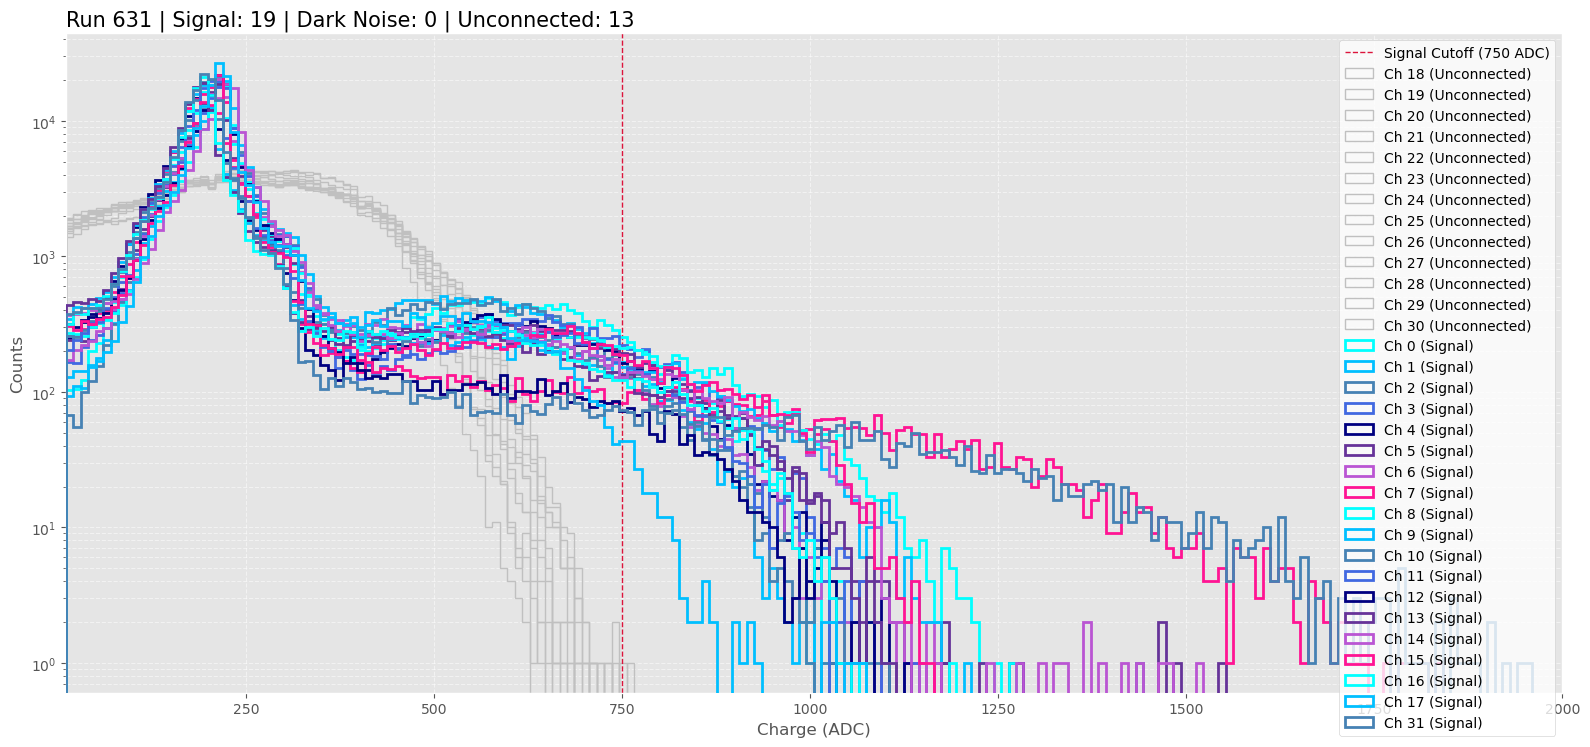


--- Module Commissioning Report: muons_run_632.h5 (73169 events, 32 readout channels) ---

[✓] ACTIVE BARS (Cosmic Scintillation)  [2]: [7, 31]
  • Ch 7: Ped. Median: 277.00 ADC | Ped. Sigma: 171.00 ADC | SNR: 1.18 | Max. Charge: 1044 ADC | P99 Charge: 852.63 ADC | Signal Hits: 271
  • Ch 31: Ped. Median: 278.00 ADC | Ped. Sigma: 175.00 ADC | SNR: 1.30 | Max. Charge: 1221 ADC | P99 Charge: 976.00 ADC | Signal Hits: 757

[!] DARK NOISE (SiPM biased, NO light) [16]: [0, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 14, 15, 16, 17]
  • Ch 0: Ped. Median: 207.00 ADC | Ped. Sigma: 18.00 ADC | SNR: 0.89 | Max. Charge: 659 ADC | P99 Charge: 358.00 ADC | Signal Hits: 0
  • Ch 1: Ped. Median: 220.00 ADC | Ped. Sigma: 17.00 ADC | SNR: 0.88 | Max. Charge: 1075 ADC | P99 Charge: 544.17 ADC | Signal Hits: 18
  • Ch 2: Ped. Median: 215.00 ADC | Ped. Sigma: 17.00 ADC | SNR: 0.88 | Max. Charge: 1338 ADC | P99 Charge: 576.35 ADC | Signal Hits: 22
  • Ch 3: Ped. Median: 216.00 ADC | Ped. Sigma: 17.00 ADC | SNR:

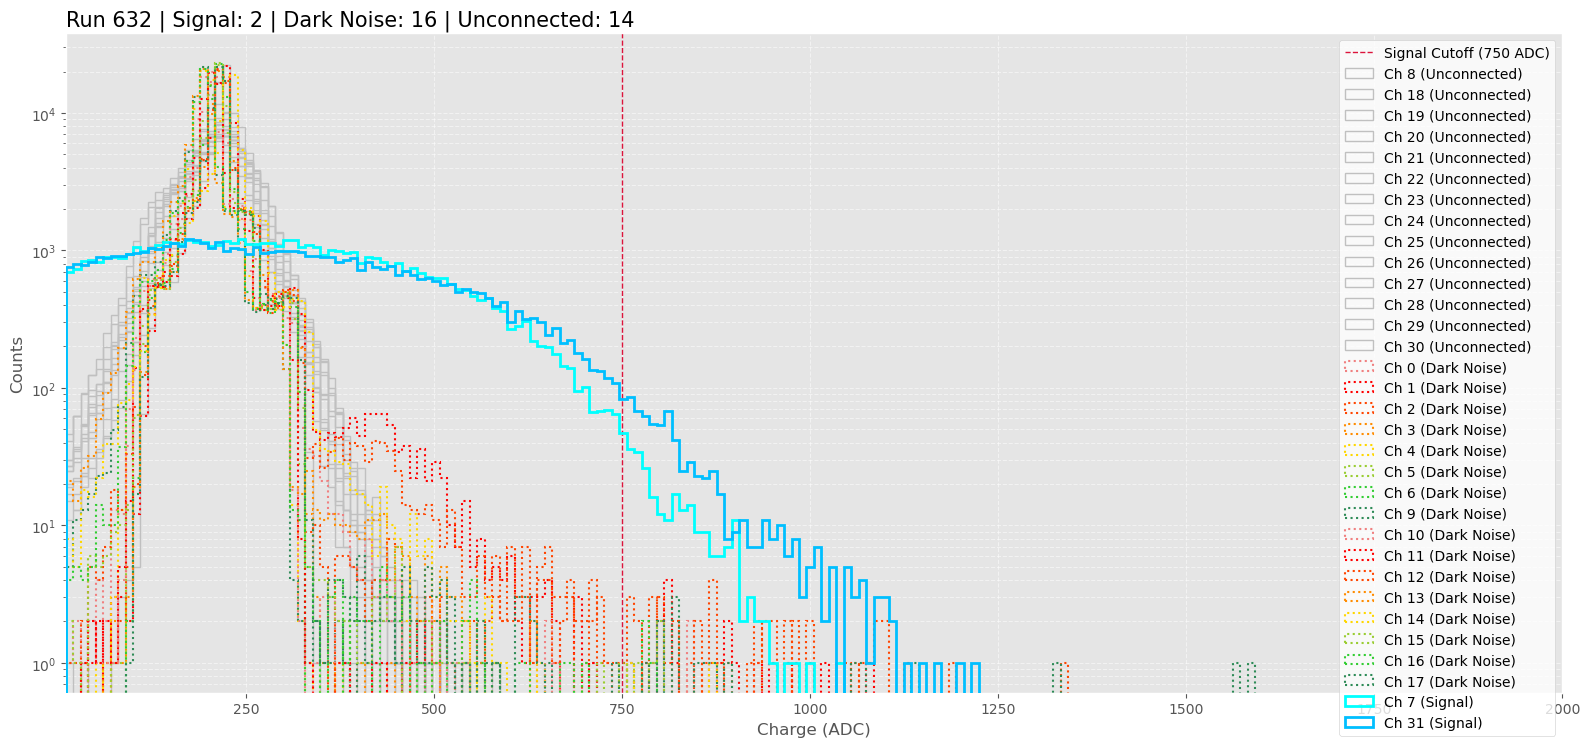


--- Custom Analysis Complete ---


In [49]:
analyze_modules(BASE_PATH, selected_runs=[625, 626, 630, 631, 632], threshold=750, plot_range=(10, 2000), bins=200, log_scale=True)


--- Custom Run Analysis Mode ---
Found 5 files to analyze.
------------------------------------------------------------
[Run 625] Using file: muons_run_625.h5


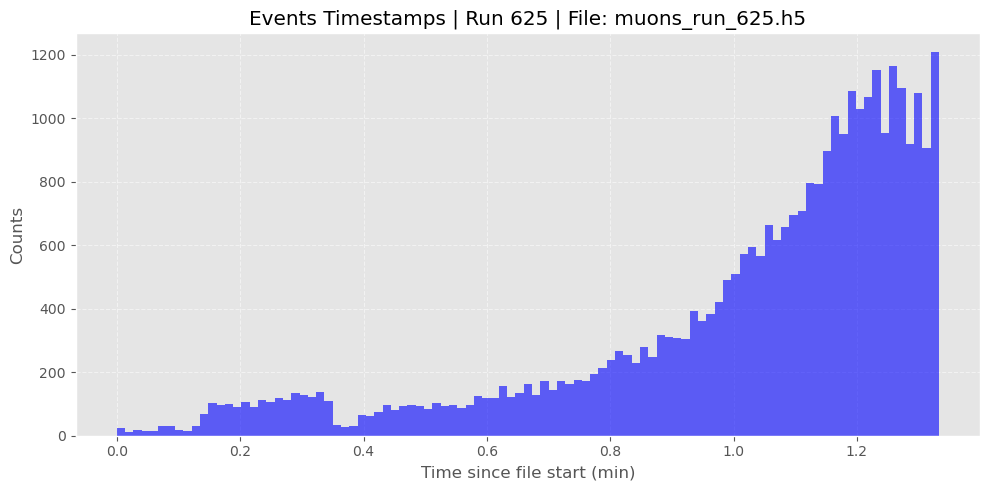

      Analyzed Time : 79.98 seconds
      Events Saved  : 32239
      Events Lost   : 437838 (from lostBuffer)
      Measured Rate : 403.09 Hz
      Lost Rate     : 5474.34 Hz (+ added by efficiency)
      FINAL RATE    : 5877.43 Hz

[Run 626] Using file: muons_run_626.h5


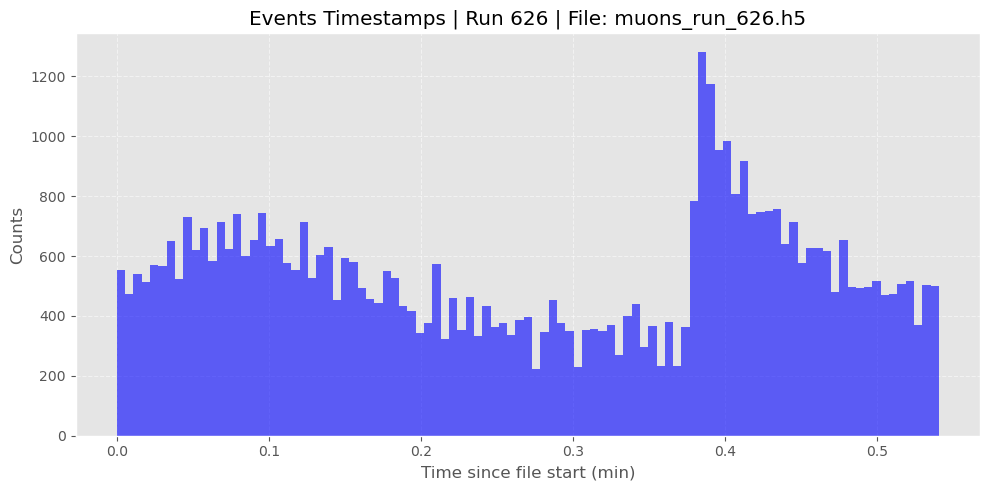

      Analyzed Time : 32.44 seconds
      Events Saved  : 53027
      Events Lost   : 692035 (from lostBuffer)
      Measured Rate : 1634.67 Hz
      Lost Rate     : 21333.43 Hz (+ added by efficiency)
      FINAL RATE    : 22968.09 Hz

[Run 630] Using file: muons_run_630.h5


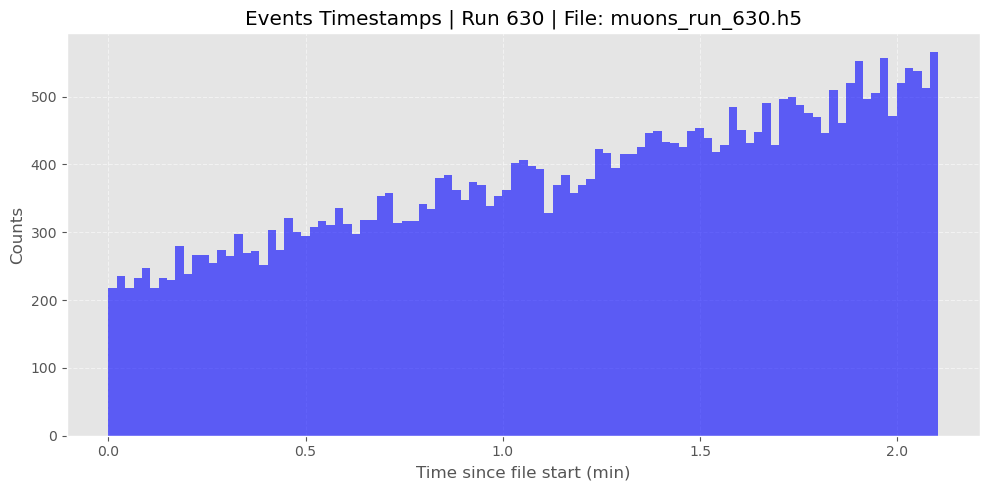

      Analyzed Time : 126.28 seconds
      Events Saved  : 37399
      Events Lost   : 532757 (from lostBuffer)
      Measured Rate : 296.17 Hz
      Lost Rate     : 4219.02 Hz (+ added by efficiency)
      FINAL RATE    : 4515.19 Hz

[Run 631] Using file: muons_run_631.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 16 events.


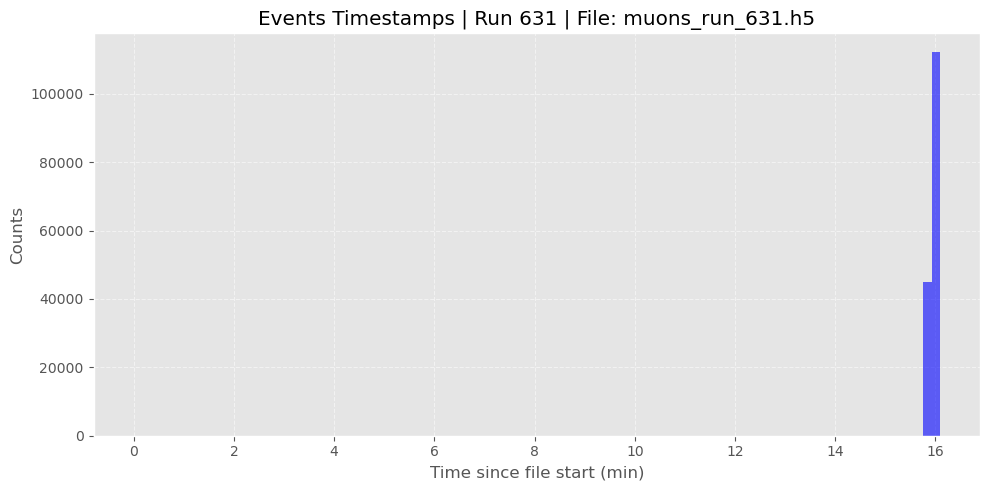

      Analyzed Time : 14.40 seconds
      Events Saved  : 157148
      Events Lost   : 2106523 (from lostBuffer)
      Measured Rate : 10914.57 Hz
      Lost Rate     : 146306.64 Hz (+ added by efficiency)
      FINAL RATE    : 157221.21 Hz

[Run 632] Using file: muons_run_632.h5
      [!] Gap Cleaning Triggered: Removed 1 gap cluster(s). Dropped 342 events.


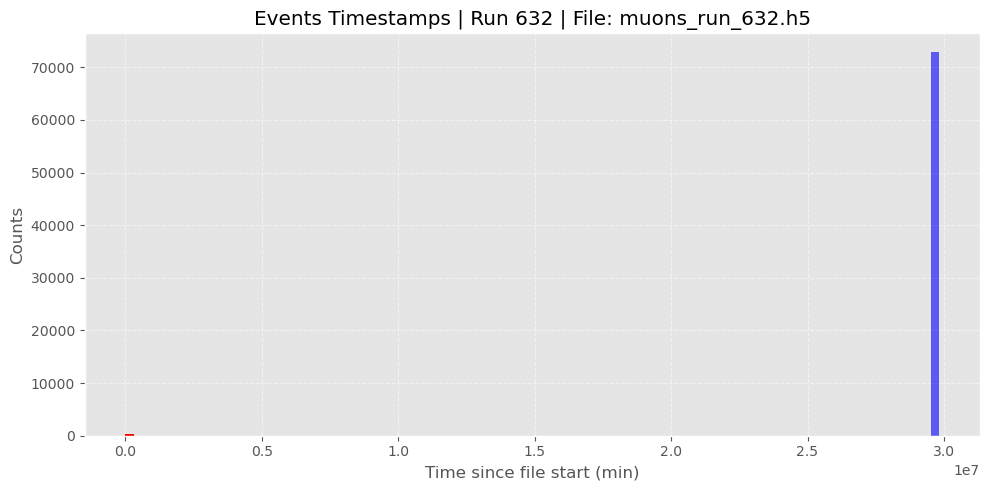

      Analyzed Time : 10.41 seconds
      Events Saved  : 72827
      Events Lost   : 1034380 (from lostBuffer)
      Measured Rate : 6996.54 Hz
      Lost Rate     : 99373.62 Hz (+ added by efficiency)
      FINAL RATE    : 106370.16 Hz



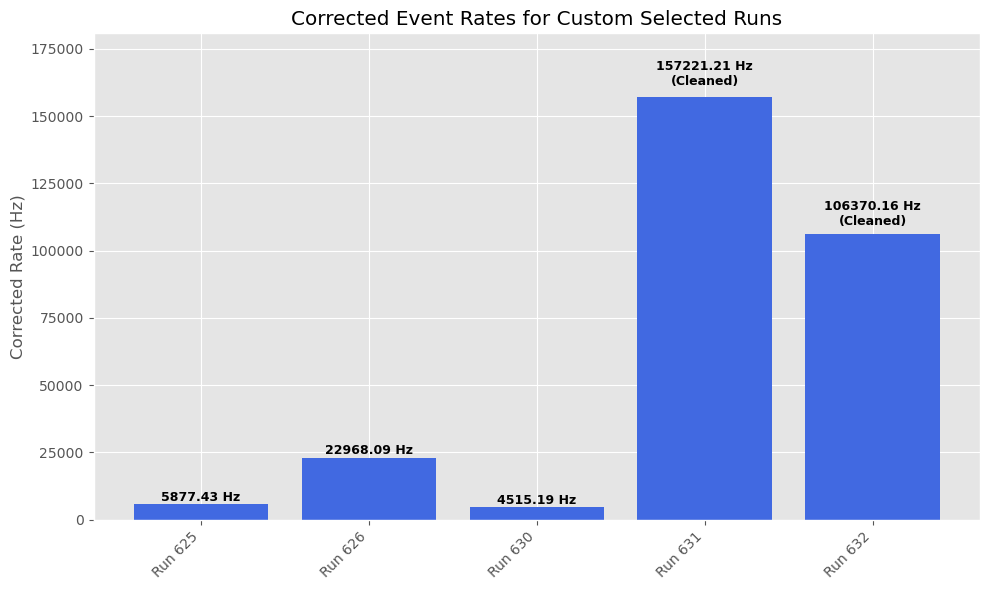

------------------------------------------------------------
Generating charge distribution plots...


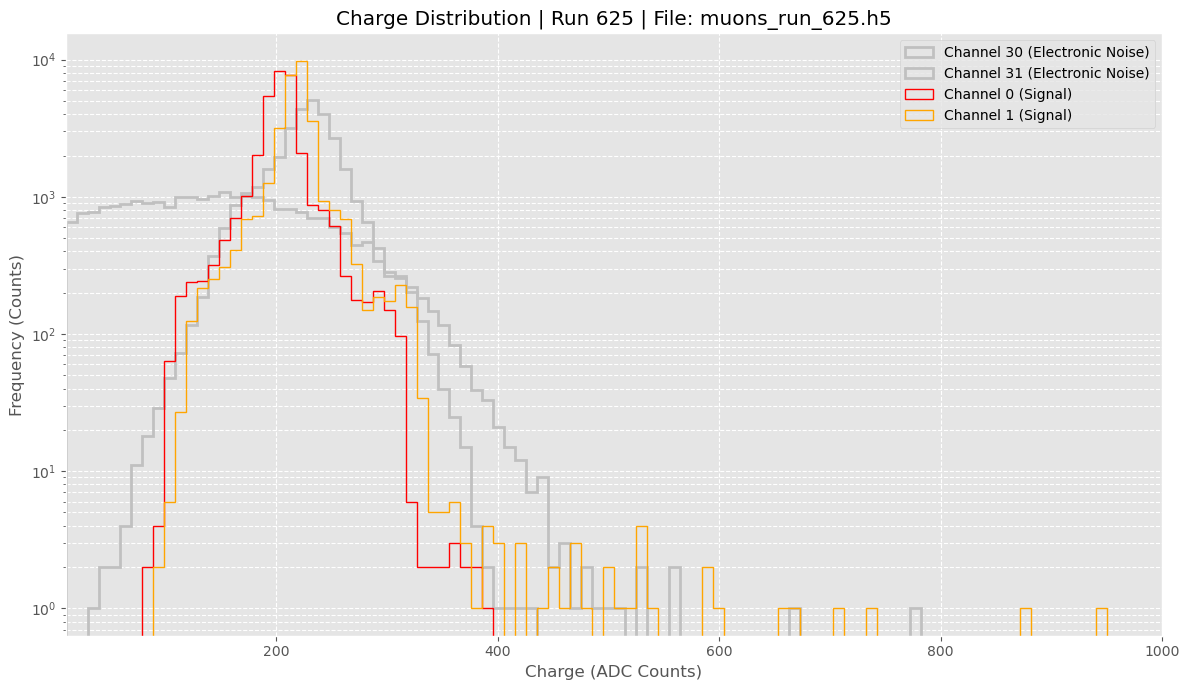

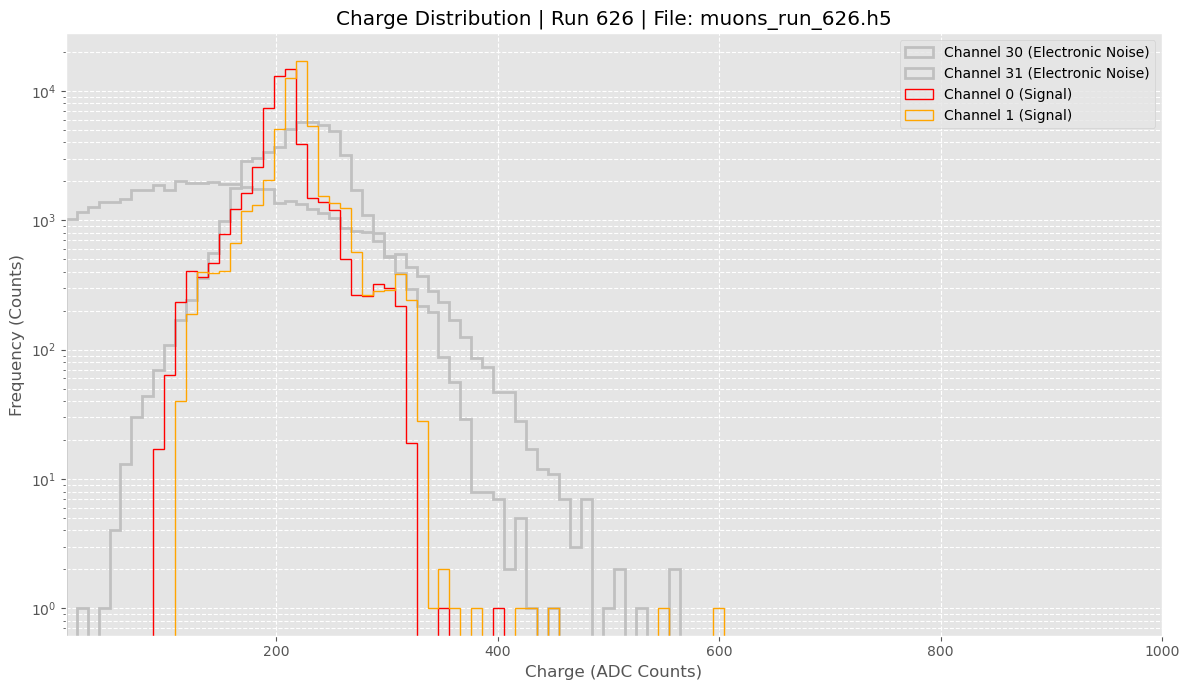

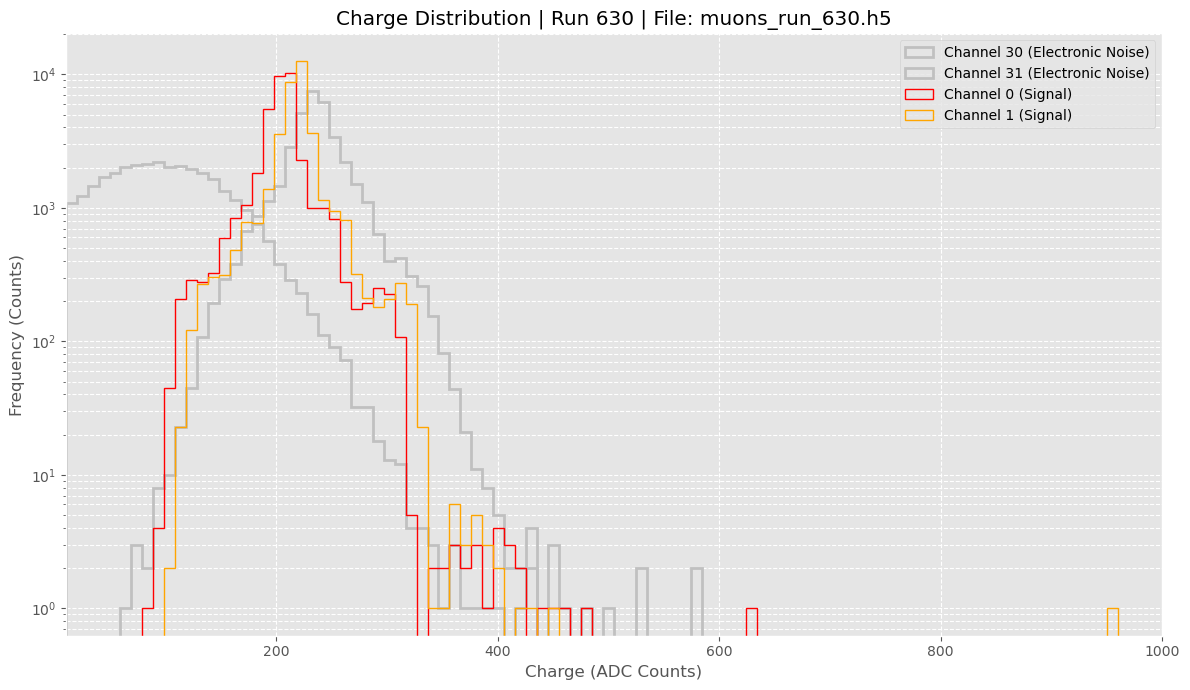

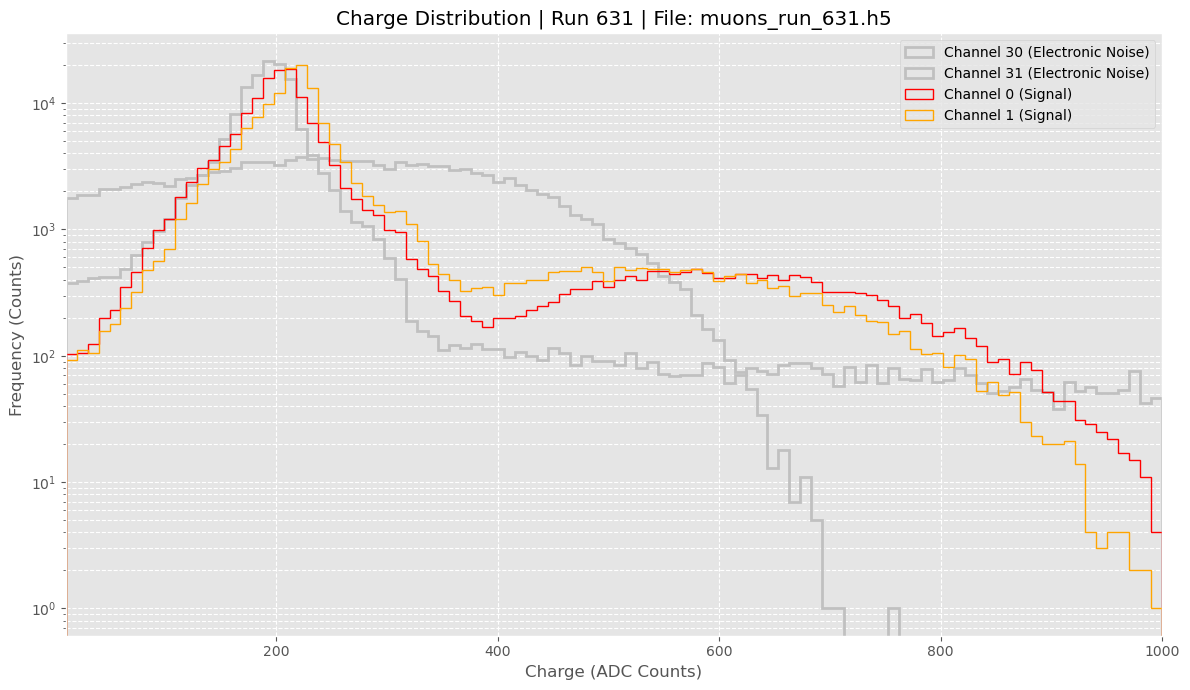

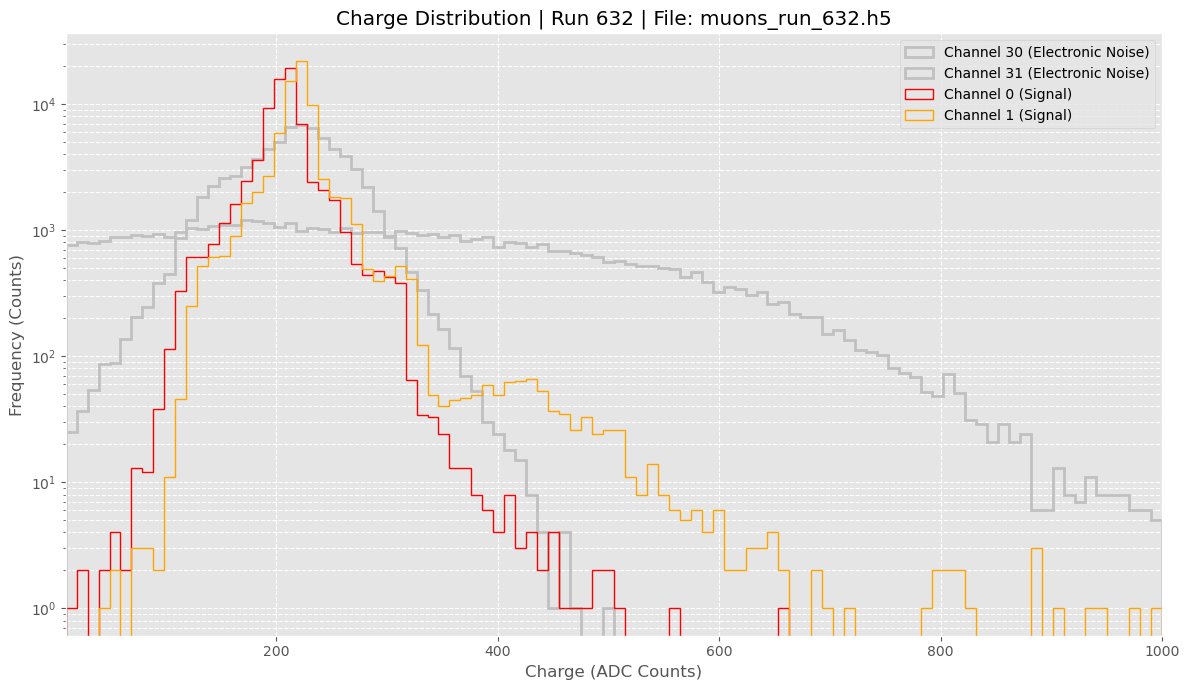


--- Custom Analysis Complete ---



In [47]:
analyze_bars(BASE_PATH, selected_runs=[625, 626, 630, 631, 632], signal_channels=[0, 1], ref_channels=[30, 31], plot_range=(10, 1000), bins=100, log_scale=True)